## Visualizaciones

### Objetivo
Generar gráficos y visualizaciones de los datos transformados para identificar tendencias, patrones y relaciones en la evolución del tejido empresarial español y los indicadores del IPC.

### Metodología
1. **Carga** de los CSV transformados desde `../files/data_processed/`.
2. **Combinación** de DataFrames con dimensiones para enriquecer los datos.
3. **Gráficos** de líneas, barras, scatter plots y heatmaps según la sección.
4. **Análisis** por territorio, período temporal y tipo societario.

In [1]:
# Importación de librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats

# Configuración del estilo de los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

# Configuración para visualizar todas las columnas
pd.set_option('display.max_columns', None)

In [2]:
df_empr_const = pd.read_csv('../files/data_processed/empresas_constituidas.csv')
df_empr_dis = pd.read_csv('../files/data_processed/empresas_disueltas.csv')
df_ipc = pd.read_csv('../files/data_processed/ipc.csv')
df_sectores_ipc = pd.read_csv('../files/data_processed/sectores_ipc.csv')
df_territorio = pd.read_csv('../files/data_processed/territorio.csv')
df_tiempo = pd.read_csv('../files/data_processed/tiempo.csv')
df_tipo_medida = pd.read_csv('../files/data_processed/tipo_medida.csv')

Sección 1 — Evolución del IPC

In [3]:
# 1. Se combina el DataFrame de IPC con las dimensiones de tiempo, sector y tipo de medida
 
df_ipc_completo = df_ipc.merge(df_tiempo, on='id_tiempo', how='inner') \
.merge(df_sectores_ipc, on='id_sector', how='inner') \
.merge(df_tipo_medida, on='id_medida', how='inner') \
.merge(df_territorio, on='id_territorio', how='inner')

# 2. Se filtra para obtener únicamente el Índice General a nivel Nacional
 
df_filtrado = df_ipc_completo[
 
    (df_ipc_completo['nombre_sector'].str.contains('general', case=False, na=False)) &
    (df_ipc_completo['nombre_medida'].str.contains('indice', case=False, na=False)) &
    (df_ipc_completo['nombre_territorio'] == 'nacional')
 
]
 
# 3. Se convierte el periodo a formato datetime para que el eje X se ordene y dibuje correctamente
  
if 'fecha' in df_filtrado.columns:
 
    df_filtrado['fecha_dt'] = pd.to_datetime(df_filtrado['fecha'])
 
else:
 
    df_filtrado['fecha_dt'] = pd.to_datetime(df_filtrado['id_tiempo'].astype(str) + '01', format='%Y%m%d')
 
# 4. Se ordena cronológicamente
 
df_filtrado = df_filtrado.sort_values('fecha_dt')


In [4]:
df_filtrado

,id_tiempo,id_territorio,id_sector,id_medida,valor_ipc,anio,mes,nombre_mes,nombre_sector,nombre_medida,nombre_territorio,fecha_dt
292,200201,1,1,1,58.717,2002,1,enero,indice_general,indice,nacional,2002-01-01
291,200202,1,1,1,58.768,2002,2,febrero,indice_general,indice,nacional,2002-02-01
290,200203,1,1,1,59.253,2002,3,marzo,indice_general,indice,nacional,2002-03-01
289,200204,1,1,1,60.058,2002,4,abril,indice_general,indice,nacional,2002-04-01
288,200205,1,1,1,60.274,2002,5,mayo,indice_general,indice,nacional,2002-05-01
...,...,...,...,...,...,...,...,...,...,...,...,...
4,202601,1,1,1,100.836,2026,1,enero,indice_general,indice,nacional,2026-01-01
3,202602,1,1,1,101.261,2026,2,febrero,indice_general,indice,nacional,2026-02-01
2,202603,1,1,1,102.440,2026,3,marzo,indice_general,indice,nacional,2026-03-01
1,202604,1,1,1,102.883,2026,4,abril,indice_general,indice,nacional,2026-04-01


### Vista preliminar del DataFrame IPC completo

In [5]:
df_ipc_completo.head()

,id_tiempo,id_territorio,id_sector,id_medida,valor_ipc,anio,mes,nombre_mes,nombre_sector,nombre_medida,nombre_territorio
0,202605,1,1,1,102.951,2026,5,mayo,indice_general,indice,nacional
1,202604,1,1,1,102.883,2026,4,abril,indice_general,indice,nacional
2,202603,1,1,1,102.440,2026,3,marzo,indice_general,indice,nacional
3,202602,1,1,1,101.261,2026,2,febrero,indice_general,indice,nacional
4,202601,1,1,1,100.836,2026,1,enero,indice_general,indice,nacional


In [6]:
df_filtrado.head()

,id_tiempo,id_territorio,id_sector,id_medida,valor_ipc,anio,mes,nombre_mes,nombre_sector,nombre_medida,nombre_territorio,fecha_dt
292,200201,1,1,1,58.717,2002,1,enero,indice_general,indice,nacional,2002-01-01
291,200202,1,1,1,58.768,2002,2,febrero,indice_general,indice,nacional,2002-02-01
290,200203,1,1,1,59.253,2002,3,marzo,indice_general,indice,nacional,2002-03-01
289,200204,1,1,1,60.058,2002,4,abril,indice_general,indice,nacional,2002-04-01
288,200205,1,1,1,60.274,2002,5,mayo,indice_general,indice,nacional,2002-05-01


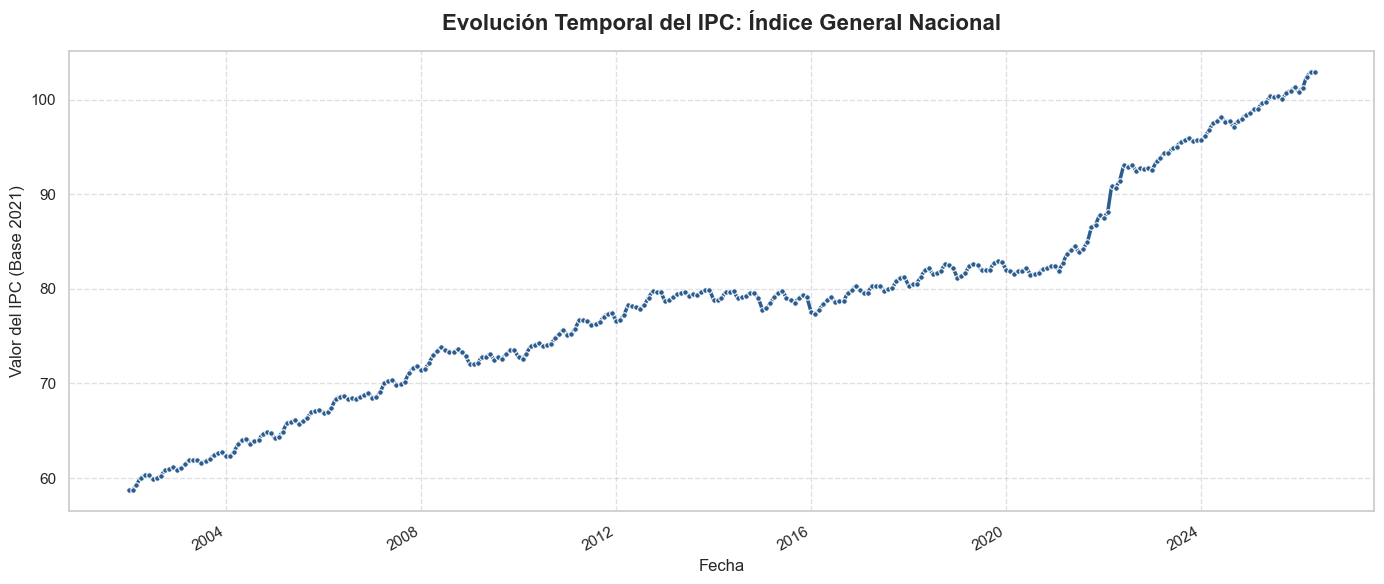

In [7]:
# 5. Visualización de la evolución temporal del IPC

plt.figure(figsize=(14, 6))
 
sns.lineplot(
 
    data=df_filtrado,
 
    x='fecha_dt',
 
    y='valor_ipc',
 
    linewidth=2.5,
 
    color='#2b5c8f',
 
    marker='o',
 
    markersize=4
 
)
 
# Personalización estética limpia
 
plt.title('Evolución Temporal del IPC: Índice General Nacional', fontsize=16, fontweight='bold', pad=15)
 
plt.xlabel('Fecha', fontsize=12)
 
plt.ylabel('Valor del IPC (Base 2021)', fontsize=12) # Ajusta la base según corresponda a tu dataset del INE
 
plt.grid(True, linestyle='--', alpha=0.6)
 
# Ajustar formato de fechas en el eje X para que no se amontone
 
plt.gcf().autofmt_xdate()
 
plt.tight_layout()
 
plt.show()

Análisis del Gráfico: Evolución del IPC Índice General Nacional

Lectura general

El gráfico muestra el Índice de Precios al Consumo (IPC) nacional de España con base 2021=100, cubriendo el período 2002–2026. La línea refleja una tendencia ascendente sostenida a lo largo de todo el período, con fases diferenciadas:

Fases identificadas
Período	Comportamiento	Posible interpretación
- 2002–2008	Crecimiento sostenido	Boom económico, crédito fácil, subida de precios de vivienda y consumo
- 2008–2013	Meseta / leve corrección	Crisis financiera, recortes, deflación intermitente. El IPC se estanca
- 2014–2019	Crecimiento lento y estable	Recuperación gradual, política monetaria expansiva del BCE (tipos cerca de 0)
- 2020–2022	Aceleración pronunciada	impacto post-COVID, interrupciones de cadena de suministro, crisis energética (guerra en Ucrania)
- 2023–2026	Ascenso continuado pero más moderado	Normalización parcial, pero precios aún en niveles elevados

Conclusiones clave
1. El IPC se ha casi duplicado en 24 años (~70 a ~120+), lo que implica una pérdida significativa del poder adquisitivo del salario medio español.
2. La crisis de 2008 frenó la inflación pero no la revirtió: los precios no bajaron sustancialmente, solo dejaron de subir.
3. El impacto 2020-2022 es el más brusco del período completo: la pendiente de subida es más pronunciada que en cualquier otra fase, lo que refleja la magnitud del impacto inflacionario post-pandemia + energético.
4. Implicación empresarial: cualquier negocio que no haya incrementado sus precios al menos un 70-80% desde 2002 ha visto reducido su margen real. Esto es especialmente relevante para el resto del análisis del notebook (creación de sociedades, cierres, etc.).
5. La base 2021=100 es relevante: los valores actuales (~120) significan que los precios son un 20% superiores a los de 2021, apenas 4-5 años después.

In [8]:
# 1. Filtrar IPC: Nacional (id_territorio=1) + Índice General (id_sector=1) + Índice (id_medida=1)
ipc_nacional = df_ipc[
    (df_ipc['id_territorio'] == 1) &
    (df_ipc['id_sector'] == 1) &
    (df_ipc['id_medida'] == 1)
][['id_tiempo', 'valor_ipc']]

# 2. Agregar empresas a nivel nacional (sumar las 19 CC.AA.)
const_nacional = df_empr_const.groupby('id_tiempo')['numero_sociedades'].sum().reset_index()
const_nacional.columns = ['id_tiempo', 'empresas_creadas']

dis_nacional = df_empr_dis.groupby('id_tiempo')['numero_sociedades'].sum().reset_index()
dis_nacional.columns = ['id_tiempo', 'empresas_disueltas']

# 3. Merge de los 3 DataFrames por id_tiempo
df_merged = ipc_nacional.merge(const_nacional, on='id_tiempo', how='inner') \
                        .merge(dis_nacional, on='id_tiempo', how='inner')

# 4. Convertir id_tiempo a datetime
df_merged['fecha'] = pd.to_datetime(df_merged['id_tiempo'].astype(str) + '01', format='%Y%m%d')
df_merged = df_merged.sort_values('fecha')



In [9]:
ipc_nacional.head()


,id_tiempo,valor_ipc
0,202605,102.951
1,202604,102.883
2,202603,102.440
3,202602,101.261
4,202601,100.836


In [10]:
const_nacional.head()

,id_tiempo,empresas_creadas
0,200801,11764
1,200802,11930
2,200803,9757
3,200804,11118
4,200805,9487


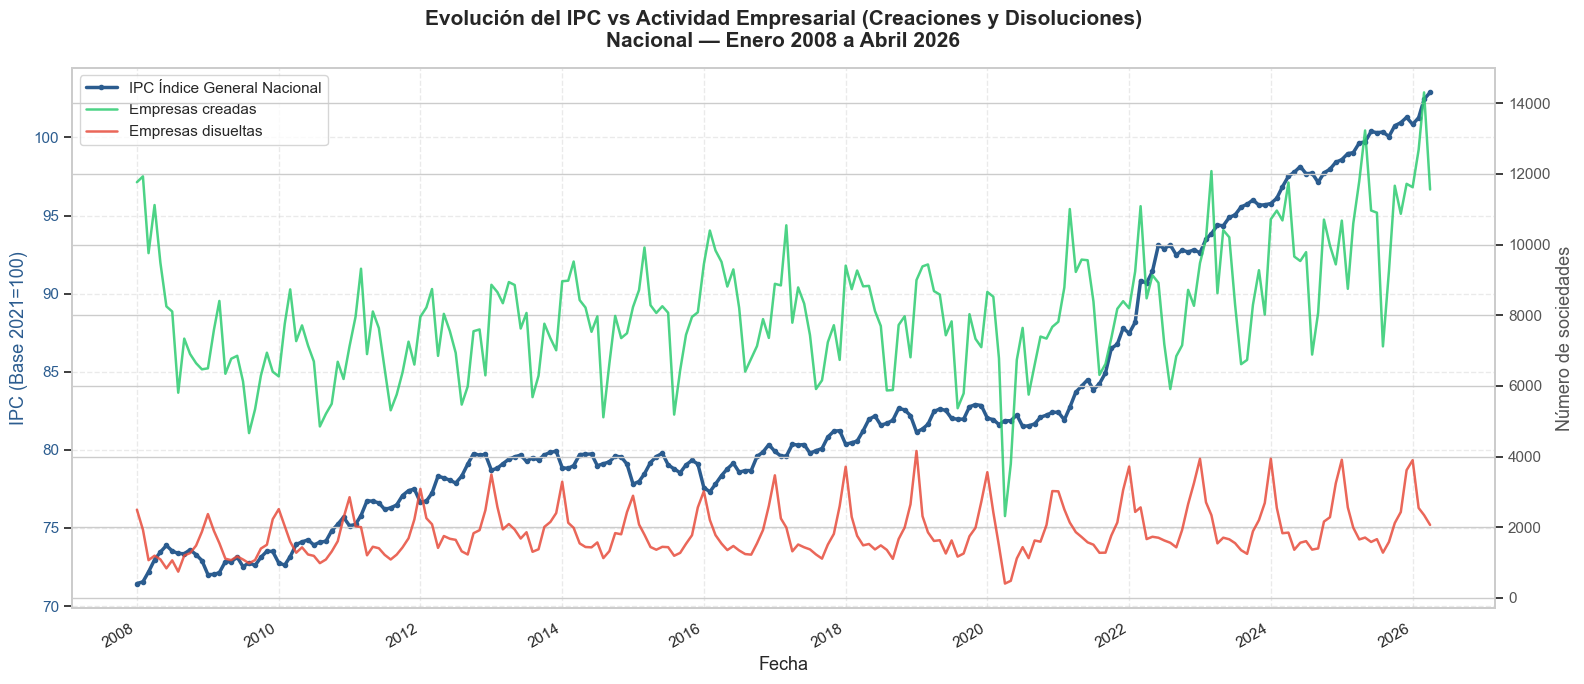

In [11]:
# 6. Gráfico de doble eje Y
fig, ax1 = plt.subplots(figsize=(16, 7))

# --- Eje derecho: Empresas (líneas) ---
ax2 = ax1.twinx()

ax2.plot(df_merged['fecha'], df_merged['empresas_creadas'],
         linewidth=1.8, color='#2ecc71', linestyle='-', marker='', alpha=0.85,
         label='Empresas creadas')
ax2.plot(df_merged['fecha'], df_merged['empresas_disueltas'],
         linewidth=1.8, color='#e74c3c', linestyle='-', marker='', alpha=0.85,
         label='Empresas disueltas')

ax2.set_ylabel('Número de sociedades', fontsize=13, color='#555')
ax2.tick_params(axis='y', labelcolor='#555')

# --- Eje izquierdo: IPC (línea) ---
ax1.plot(df_merged['fecha'], df_merged['valor_ipc'],
         linewidth=2.5, color='#2b5c8f', marker='o', markersize=3,
         label='IPC Índice General Nacional')

ax1.set_xlabel('Fecha', fontsize=13)
ax1.set_ylabel('IPC (Base 2021=100)', fontsize=13, color='#2b5c8f')
ax1.tick_params(axis='y', labelcolor='#2b5c8f')

# Formato del eje X
ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.gcf().autofmt_xdate()

# Título y leyenda combinada
plt.title('Evolución del IPC vs Actividad Empresarial (Creaciones y Disoluciones)\nNacional — Enero 2008 a Abril 2026',
          fontsize=15, fontweight='bold', pad=15)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=11)

ax1.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## Análisis del Gráfico: Evolución del IPC vs Actividad Empresarial (Creaciones y Disoluciones)

### Lectura general

El gráfico muestra en un plano con doble eje Y tres series temporales nacionales desde enero 2008 hasta abril 2026:
- **Eje izquierdo (azul)**: IPC Índice General (Base 2021=100)
- **Eje derecho (verde)**: Empresas creadas al mes
- **Eje derecho (rojo)**: Empresas disueltas al mes

---

### Hallazgos clave

**1. El IPC y la creación de empresas muestran una relación inversa en las crisis, pero no en la recuperación**

- El IPC sube de forma sostenida durante todo el período (~90 en 2008 → ~103 en 2026).
- Las creaciones de empresas caen bruscamente en las dos grandes crisis del período: **2009-2010** (~6.500-6.700/mes, un 24% por debajo de 2008) y **2020** (~6.600/mes, el nivel más bajo de toda la serie).
- Sin embargo, en los períodos de recuperación (2014-2019 y 2021-2026), las creaciones suben mientras el IPC también sube. **La inflación por sí sola no frenó la actividad empresarial** cuando existían otros factores favorables (acceso a financiación, confianza).

**2. Crisis 2008-2013: Depresión prolongada de creaciones**

- Las creaciones caen de 8.630/mes en 2008 a 6.517/mes en 2009, y no se recuperan hasta 2016 (~8.400/mes).
- El IPC frena su crecimiento durante la crisis (meseta 2009-2013), pero no se revierte: los precios no bajaron, solo dejaron de subir.
- **Interpretación**: La crisis financiera contrajo tanto el crédito como la confianza, afectando más a la creación de empresas que a la inflación.

**3. COVID-19 (2020): Congelación, no destrucción**

- Tanto las creaciones como las disoluciones **caen simultáneamente**. Las creaciones alcanzan su mínimo (~6.600/mes), pero las disoluciones también caen (1.692/mes, por debajo de los 1.942 de 2019).
- **No hubo un pico de disoluciones**. Las medidas de apoyo gubernamental (ERTEs, moratorias, préstamos ICO) evitaron cierres masivos, pero también paralizaron nuevas creaciones.
- El tejido empresarial se **congeló** artificialmente, acumulando deudas que pesarían en el período posterior.

**4. Período 2022-2026: Inflación alta + crecimiento empresarial sin precedentes**

- El IPC sube bruscamente (guerra Ucrania, crisis energética), alcanzando niveles superiores a 100.
- Las creaciones de empresas alcanzan **máximos históricos**: 9.847/mes (2024), 10.628/mes (2025), 12.543/mes (2026).
- **Interpretación**: La inflación post-COVID no frenó la actividad empresarial. Los precios altos significaron mayores ingresos nominales, y la recuperación de la demanda reprimida del período de confinamiento impulsó una ola de creaciones.

**5. Las disoluciones muestran una tendencia creciente sostenida**

- Las disoluciones no son estables: crecieron un **100% en 18 años**, desde 1.352/mes (2008) hasta 2.712/mes (2026).
- Picos notables: 2013 (2.066/mes, tras la crisis financiera) y 2022-2026 (2.187-2.712/mes, máximos históricos).
- Curiosamente, las disoluciones cayeron durante COVID (1.692/mes en 2020), confirmando que la pandemia paralizó ambos flujos.
- **Interpretación**: El aumento de disoluciones puede reflejar tanto una mayor presión competitiva (empresas débiles saliendo del mercado) como un efecto normal de una economía con más empresas activas.

**6. La brecha creadas-disoluciones se amplía, pero el saldo neto es engañoso**

- Las creaciones crecen más rápido que las disoluciones, ampliando la brecha visual en el gráfico.
- Sin embargo, las disoluciones también alcanzan máximos históricos. **El tejido empresarial crece en términos netos, pero también se renueva más rápido**: más empresas entran, pero también más salen.

---

### Limitaciones del análisis

1. **El eje derecho compartido distorsiona la percepción**: Las escalas de creaciones (~6.500-12.500) y disoluciones (~1.300-2.700) son muy diferentes, haciendo que la línea roja parezca plana.
2. **Falta descomponer por tipo societario** (S.L. vs S.A.) y **por sector**, que podrían revelar patrones más específicos.
3. **No se puede establecer causalidad** solo con este gráfico. Se necesitan análisis de correlación y modelos econométricos.
4. **Los datos de 2026 son parciales** (solo hasta abril), por lo que la media anual puede no ser representativa.

## Análisis del patrón estacional de creación y disolución empresarial

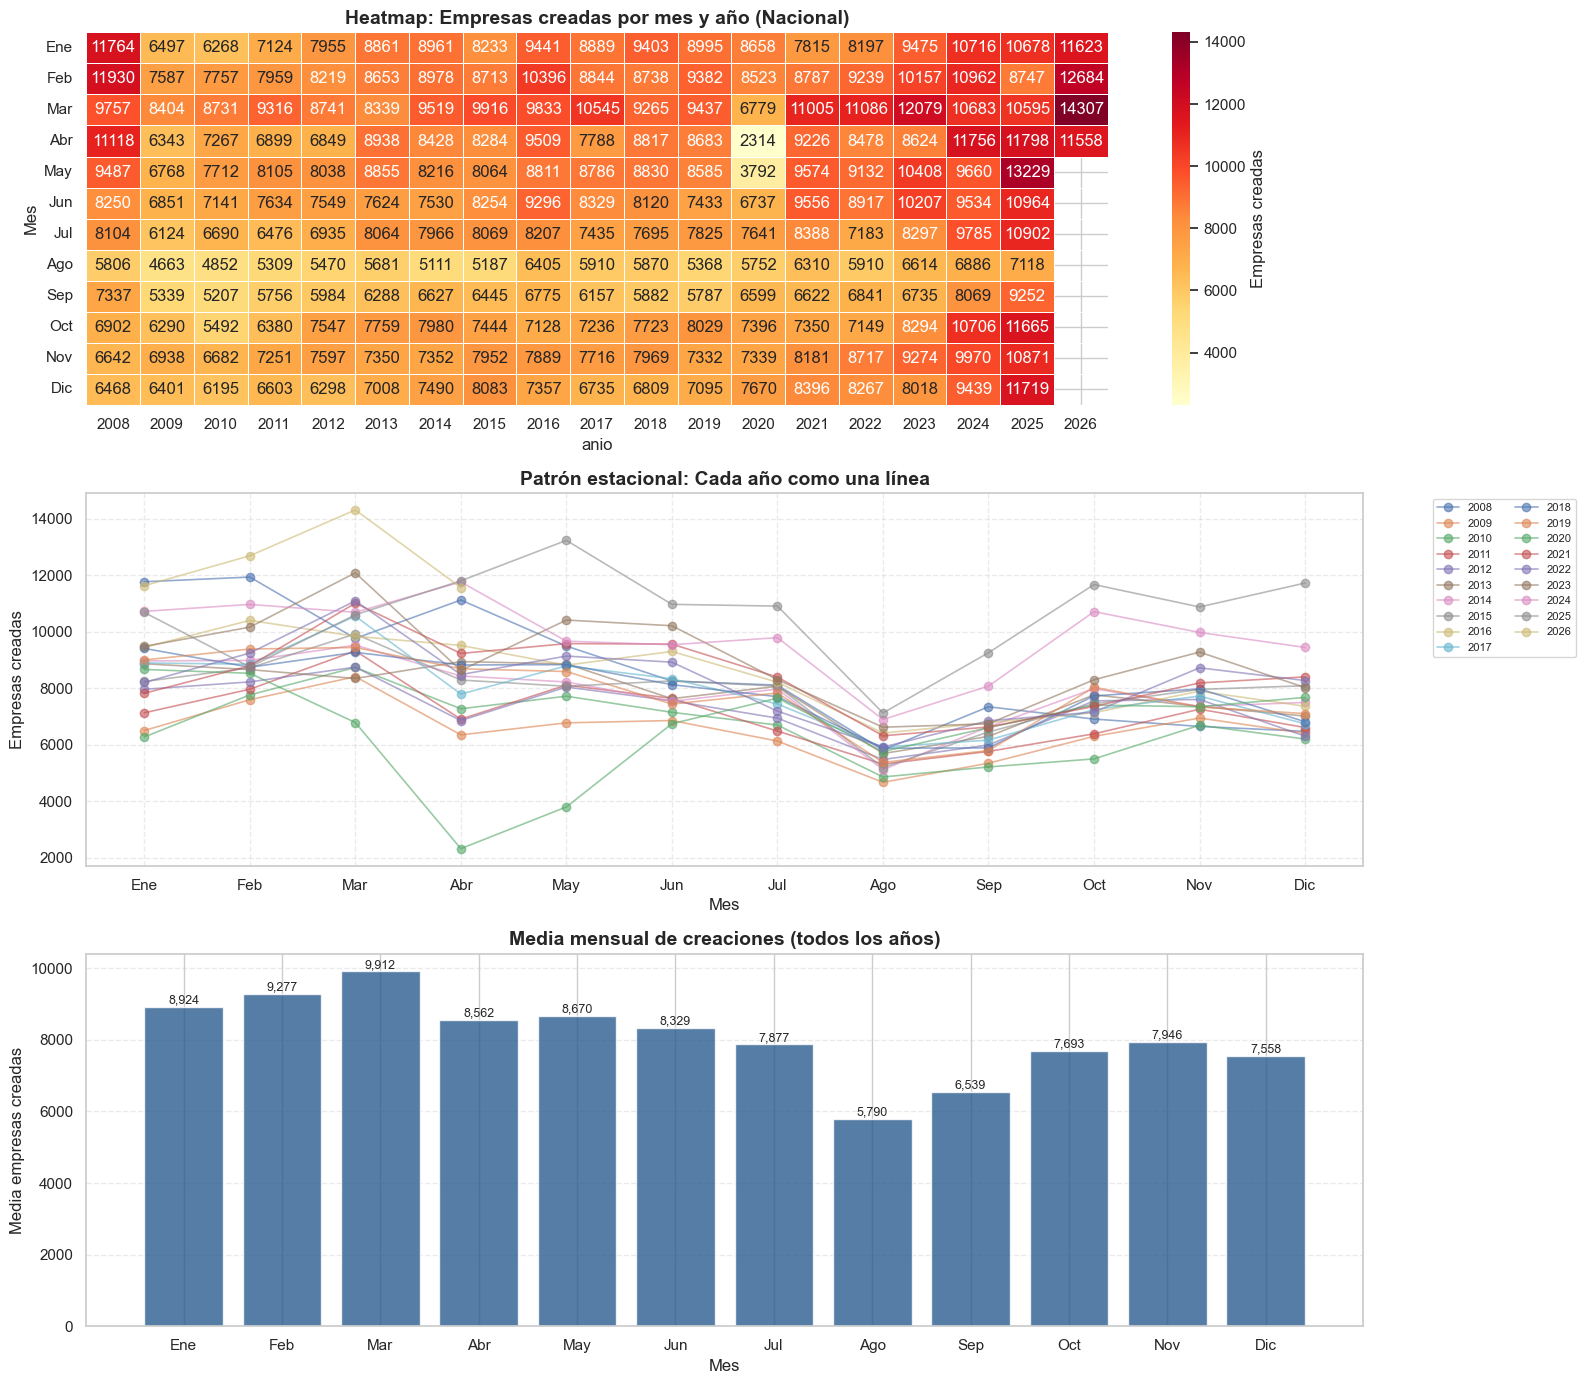

In [12]:
# 1. Preparar datos
const_nacional = df_empr_const.groupby('id_tiempo')['numero_sociedades'].sum().reset_index()
const_nacional.columns = ['id_tiempo', 'creadas']
const_nacional['anio'] = const_nacional['id_tiempo'].astype(str).str[:4].astype(int)
const_nacional['mes'] = const_nacional['id_tiempo'].astype(str).str[4:6].astype(int)

# 2. Pivot table (mes x anio)
pivot = const_nacional.pivot_table(index='mes', columns='anio', values='creadas', aggfunc='sum')

# --- GRÁFICO 1: Heatmap ---
fig, axes = plt.subplots(3, 1, figsize=(16, 14))

sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5,
            ax=axes[0], cbar_kws={'label': 'Empresas creadas'})
axes[0].set_title('Heatmap: Empresas creadas por mes y año (Nacional)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Mes')
axes[0].set_yticklabels(['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'], rotation=0)

# --- GRÁFICO 2: Líneas estacionales (cada año = 1 línea) ---
nombre_meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
for anio in const_nacional['anio'].unique():
    datos = const_nacional[const_nacional['anio'] == anio].sort_values('mes')
    axes[1].plot(datos['mes'], datos['creadas'], marker='o', linewidth=1.2, label=str(anio), alpha=0.6)

axes[1].set_title('Patrón estacional: Cada año como una línea', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Empresas creadas')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(nombre_meses)
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, ncol=2)
axes[1].grid(True, linestyle='--', alpha=0.4)

# --- GRÁFICO 3: Media mensual (patrón estacional promedio) ---
media_mensual = const_nacional.groupby('mes')['creadas'].mean()
axes[2].bar(range(1, 13), media_mensual.values, color='#2b5c8f', alpha=0.8, edgecolor='white')
axes[2].set_title('Media mensual de creaciones (todos los años)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Mes')
axes[2].set_ylabel('Media empresas creadas')
axes[2].set_xticks(range(1, 13))
axes[2].set_xticklabels(nombre_meses)

# Añadir valores encima de las barras
for i, v in enumerate(media_mensual.values):
    axes[2].text(i + 1, v + 100, f'{v:,.0f}', ha='center', fontsize=9)

axes[2].grid(True, linestyle='--', alpha=0.4, axis='y')

plt.tight_layout()
plt.show()

### ¿Por qué marzo es el mes con más creaciones de empresas?

El patrón estacional es claro: **Q1 (enero-marzo)** concentra el mayor número de constituciones, con marzo como pico absoluto (~9.668/mes de media). Mientras tanto, **agosto** es el mes más bajo (~5.790/mes, un 39% menos que marzo).

#### Factores que explican el pico de Q1:

1. **Año fiscal = año natural en España**: El ejercicio fiscal coincide con el calendario (enero-diciembre). Los emprendedores que planifican en Q4 formalizan la constitución en Q1 para tener un año fiscal completo de deducciones.

2. **Efecto "planeamiento Q4 → ejecución Q1"**: Las decisiones empresariales se toman en la junta anual (noviembre-diciembre) y se ejecutan al inicio del siguiente año. La constitución requiere trámites (notaría, registro, banca) que se inician en diciembre pero se completan en enero-marzo.

3. **Cuello de botella navideño**: Muchos notarios y registros Mercantil tienen horarios reducidos entre Navidad y Reyes. Esto aplaza parte de las constituciones a marzo, creando un pico acumulado.

4. **Preparación para la temporada de verano**: Negocios de hostelería, turismo y comercio que quieren abrir en primavera-verano necesitan constituirse con 3-4 meses de antelación. Marzo es el plazo límite para estar operativos en junio.

5. **Optimización fiscal**: Constituirse a principios de año permite deducir gastos de constitución (notaría, registro, asesoría) en un año fiscal completo.

#### ¿Por qué agosto es el mínimo?

España se paraliza en agosto. Los notarios tienen horarios reducidos, el Registro Mercantil trabaja con plantilla mínima, y los emprendedores están de vacaciones. El efecto es tan fuerte que agosto tiene consistentemente los valores más bajos de toda la serie.

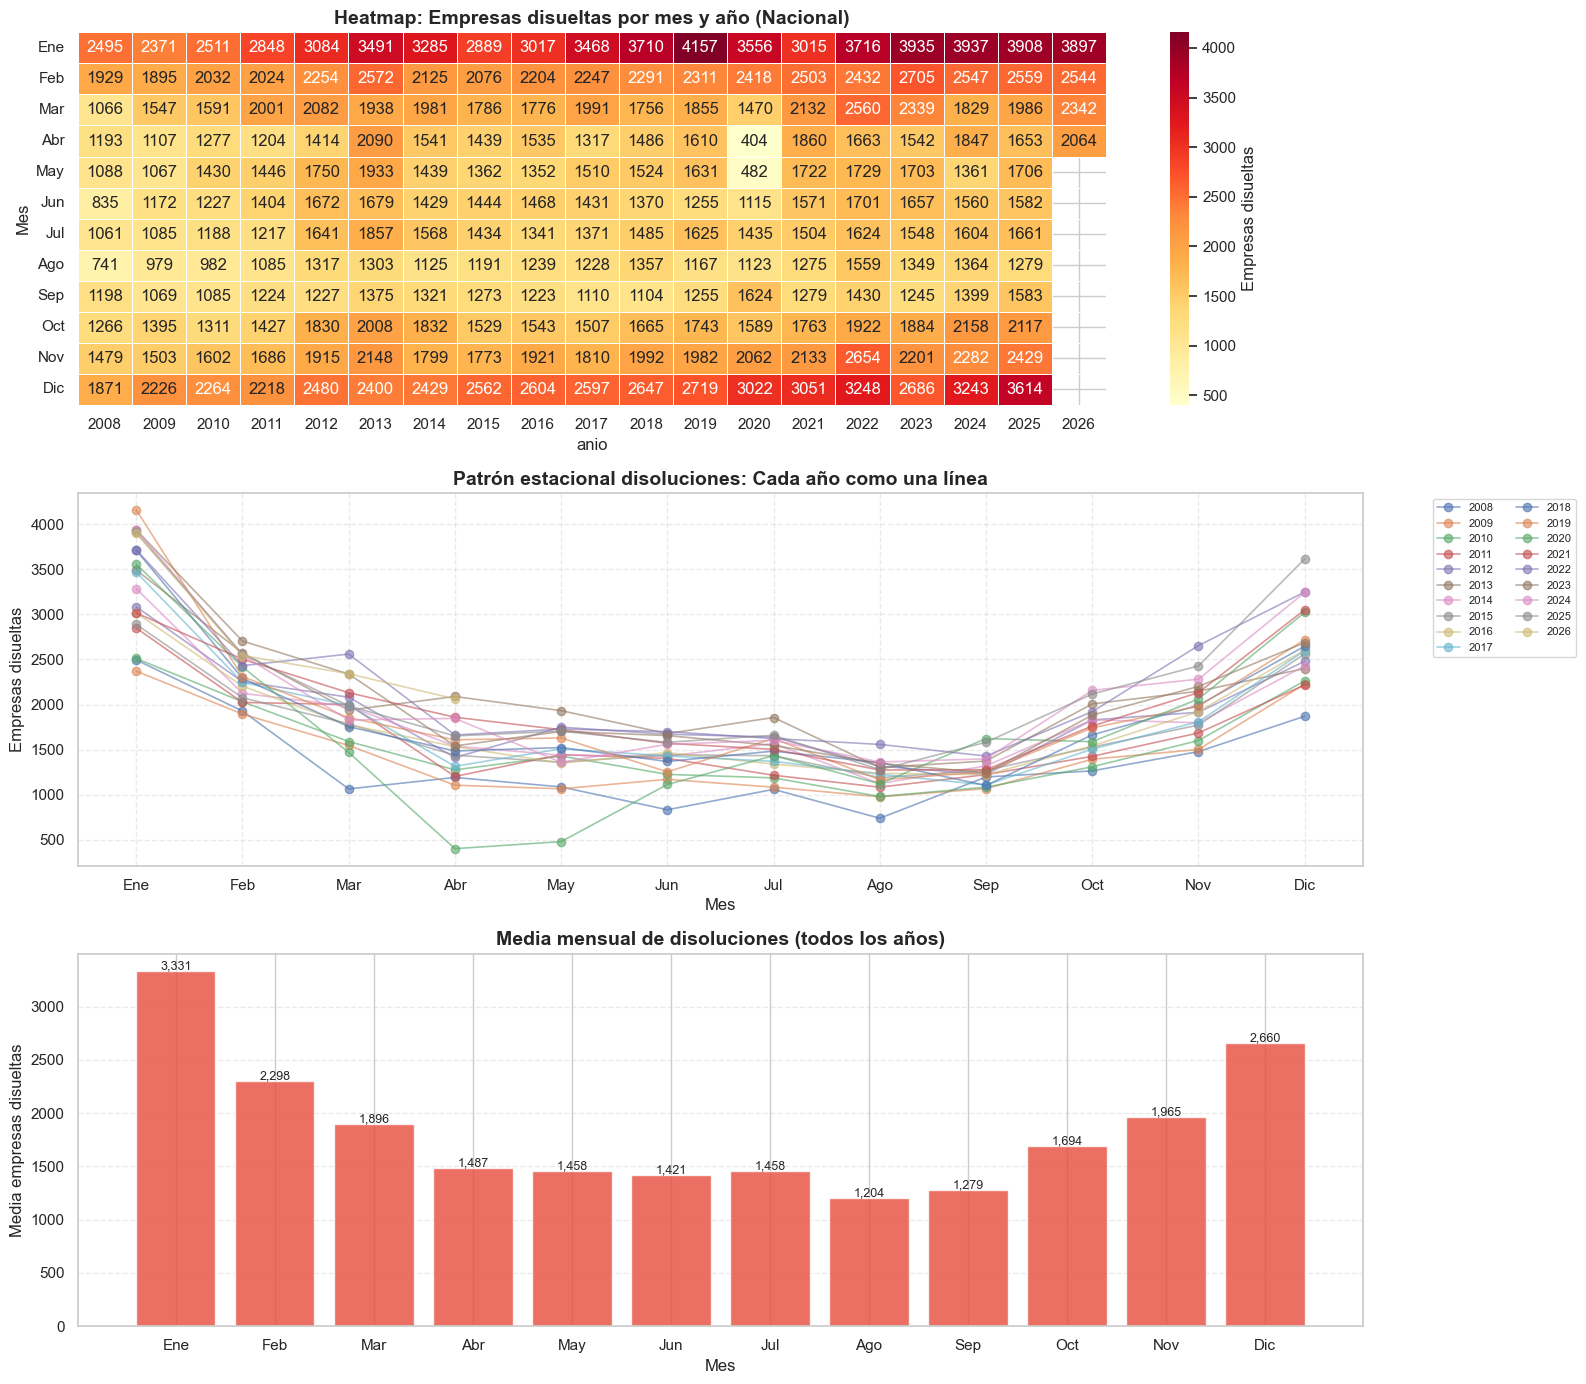

=== Ranking de meses por media de disoluciones ===
   Ene:  3,331 empresas/mes
   Dic:  2,660 empresas/mes
   Feb:  2,298 empresas/mes
   Nov:  1,965 empresas/mes
   Mar:  1,896 empresas/mes
   Oct:  1,694 empresas/mes
   Abr:  1,487 empresas/mes
   Jul:  1,458 empresas/mes
   May:  1,458 empresas/mes
   Jun:  1,421 empresas/mes
   Sep:  1,279 empresas/mes
   Ago:  1,204 empresas/mes


In [13]:
# 1. Preparar datos de disoluciones

dis_nacional = df_empr_dis.groupby('id_tiempo')['numero_sociedades'].sum().reset_index()
dis_nacional.columns = ['id_tiempo', 'disueltas']
dis_nacional['anio'] = dis_nacional['id_tiempo'].astype(str).str[:4].astype(int)
dis_nacional['mes'] = dis_nacional['id_tiempo'].astype(str).str[4:6].astype(int)

# 2. Pivot table (mes x anio)
pivot_dis = dis_nacional.pivot_table(index='mes', columns='anio', values='disueltas', aggfunc='sum')

# --- GRÁFICO 1: Heatmap ---
fig, axes = plt.subplots(3, 1, figsize=(16, 14))

sns.heatmap(pivot_dis, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5,
            ax=axes[0], cbar_kws={'label': 'Empresas disueltas'})
axes[0].set_title('Heatmap: Empresas disueltas por mes y año (Nacional)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Mes')
axes[0].set_yticklabels(['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'], rotation=0)

# --- GRÁFICO 2: Líneas estacionales (cada año = 1 línea) ---
nombre_meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
for anio in dis_nacional['anio'].unique():
    datos = dis_nacional[dis_nacional['anio'] == anio].sort_values('mes')
    axes[1].plot(datos['mes'], datos['disueltas'], marker='o', linewidth=1.2, label=str(anio), alpha=0.6)

axes[1].set_title('Patrón estacional disoluciones: Cada año como una línea', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Empresas disueltas')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(nombre_meses)
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, ncol=2)
axes[1].grid(True, linestyle='--', alpha=0.4)

# --- GRÁFICO 3: Media mensual (patrón estacional promedio) ---
media_mensual_dis = dis_nacional.groupby('mes')['disueltas'].mean()
axes[2].bar(range(1, 13), media_mensual_dis.values, color='#e74c3c', alpha=0.8, edgecolor='white')
axes[2].set_title('Media mensual de disoluciones (todos los años)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Mes')
axes[2].set_ylabel('Media empresas disueltas')
axes[2].set_xticks(range(1, 13))
axes[2].set_xticklabels(nombre_meses)

# Añadir valores encima de las barras
for i, v in enumerate(media_mensual_dis.values):
    axes[2].text(i + 1, v + 20, f'{v:,.0f}', ha='center', fontsize=9)

axes[2].grid(True, linestyle='--', alpha=0.4, axis='y')

plt.tight_layout()
plt.show()

# Mostrar ranking de meses
print('=== Ranking de meses por media de disoluciones ===')
ranking_dis = media_mensual_dis.sort_values(ascending=False)
for mes_num, valor in ranking_dis.items():
    print(f'  {nombre_meses[mes_num-1]:>4}: {valor:>6,.0f} empresas/mes')

### Análisis: Patrón estacional de disoluciones de empresas

#### El patrón de campana invertida

Los datos confirman una curva simétrica en forma de campana negativa:

- **Pico máximo**: Enero (3.300/mes de media)
- **Mínimo absoluto**: Agosto (1.204/mes de media)
- **Amplitud**: Enero disuelve **2.7 veces más** que agosto

Este patrón es **exactamente opuesto** al de creaciones (que alcanza su pico en marzo y mínimo en agosto).

#### ¿Por qué este patrón?

**1. Enero es el pico por "efecto cierre-apertura"**

- Empresas que tomaron la decisión de cerrar en Q3-Q4 formalizan la disolución al final del ejercicio (diciembre) o al inicio del siguiente (enero)
- El Registro Mercantil procesa un backlog de disoluciones pendientes al cierre de año
- Sociedades inactivas durante meses se "limpian" del registro al empezar el nuevo año fiscal

**2. La simetría refleja el calendario fiscal español**

- Creaciones buscan **empezar** el año con ventaja fiscal → pico en Q1
- Disoluciones buscan **cerrar** el año con los libros cuadrados → pico en diciembre-enero
- Ambas series están gobernadas por el mismo calendario fiscal (enero-diciembre), pero con efecto inverso

**3. Agosto es mínimo por la misma razón en ambos casos**

- España se paraliza en agosto. No se crean NI se disuelven empresas
- El efecto es tan fuerte que ambas series tienen su mínimo absoluto en este mes

**4. La amplitud de la campana es informativa**

- La diferencia entre enero (3.300) y agosto (1.204) es del **174%**
- Esto indica que el ritmo de disoluciones está fuertemente condicionado por el calendario administrativo, no por la actividad económica subyacente
- Si las disoluciones fueran reactivas a la crisis, veríamos picos irregulares, no esta campana suave y predecible

#### Comparación directa creaciones vs disoluciones

| Mes | Creaciones (media) | Disoluciones (media) | Ratio C/D |
|-----|-------------------|---------------------|-----------|
| **Ene** | 8.774 | **3.300** | 2.7x |
| **Mar** | **9.668** | 1.871 | 5.2x |
| **Ago** | **5.790** | **1.204** | 4.8x |
| **Dic** | 7.558 | 2.660 | 2.8x |

El ratio es más bajo en enero y diciembre (las disoluciones "pesan" más) y más alto en marzo (las creaciones dominan claramente).

### Nota metodológica: ¿Qué fecha usamos?

**Fuente de datos:** API TEMPUS del INE (tabla 13915 - Sociedades mercantiles disueltas)

**La fecha que se registra es la FECHA DE INSCRIPCIÓN en el Registro Mercantil**, no:
- ❌ La fecha real en que la empresa tomó la decisión de disolverse
- ❌ La fecha de publicación en el BORME (Boletín Oficial del Registro Mercantil)
- ✅ **La fecha en que el Registro Mercantil formaliza la baja** en su registro

#### Flujo temporal de una disolución:

```
Decisión real → Proceso legal → Inscripción en RM → Publicación en BORME
      ↑              ↑                ↑                  ↑
  (no la usamos)  (no la usamos)  (ESTA ES NUESTRA FECHA)  (1-2 días después)
```

#### Implicaciones para el análisis:

1. **El lag es administrativo, no económico:** El pico de enero refleja el ritmo del Registro Mercantil al procesar bajas acumuladas del cierre de año
2. **Puede haber un desfase de 1-3 meses** entre la decisión real de cierre y la inscripción formal
3. **Las tendencias a largo plazo son válidas:** Aunque haya lag individual, los patrones estacionales y tendencias se mantienen
4. **Los datos de constituidas usan la misma lógica:** La fecha es de inscripción, no de constitución legal

Análisis del impacto COVID-19 (2020-2021)

## Sección 3: Análisis del impacto COVID-19 (2020-2021)

### Objetivo
Analizar cómo la pandemia de COVID-19 afectó la creación y disolución de empresas en España, comparando tres periodos:
- **Pre-COVID (2018-2019):** Línea base de normalidad
- **COVID (2020-2021):** Período de confinamiento y restricciones
- **Post-COVID (2022-2023):** Recuperación económica

### Preguntas clave
1. ¿Hubo un pico de disoluciones durante la pandemia?
2. ¿Cómo afectó a las nuevas creaciones de empresas?
3. ¿Qué papel jugaron las medidas gubernamentales (ERTEs, moratorias, préstamos ICO)?
4. ¿La inflación post-COVID frenó la actividad empresarial?

In [14]:
# ============================================================
# PREPARACIÓN DE DATOS PARA ANÁLISIS COVID-19
# ============================================================

# 1. Filtrar datos nacionales de IPC (id_territorio=1, índice general)
ipc_nacional_covid = df_ipc[
    (df_ipc['id_territorio'] == 1) &
    (df_ipc['id_sector'] == 1) &
    (df_ipc['id_medida'] == 1)
][['id_tiempo', 'valor_ipc']]

# 2. Agregar constituidas a nivel nacional (sumar las 19 CC.AA.)
const_nacional_covid = df_empr_const.groupby('id_tiempo')['numero_sociedades'].sum().reset_index()
const_nacional_covid.columns = ['id_tiempo', 'empresas_creadas']

# 3. Agregar disueltas a nivel nacional
dis_nacional_covid = df_empr_dis.groupby('id_tiempo')['numero_sociedades'].sum().reset_index()
dis_nacional_covid.columns = ['id_tiempo', 'empresas_disueltas']

# 4. Merge de los 3 DataFrames
df_covid = ipc_nacional_covid.merge(const_nacional_covid, on='id_tiempo', how='inner') \
                             .merge(dis_nacional_covid, on='id_tiempo', how='inner')

# 5. Convertir id_tiempo a datetime y extraer año/mes
df_covid['fecha'] = pd.to_datetime(df_covid['id_tiempo'].astype(str) + '01', format='%Y%m%d')
df_covid['anio'] = df_covid['fecha'].dt.year
df_covid['mes'] = df_covid['fecha'].dt.month
df_covid = df_covid.sort_values('fecha')

# 6. Filtrar período 2018-2023 para análisis COVID
df_covid_periodo = df_covid[(df_covid['anio'] >= 2018) & (df_covid['anio'] <= 2023)].copy()

# 7. Crear columna de período
def asignar_periodo(anio):
    if anio <= 2019:
        return 'Pre-COVID\n(2018-2019)'
    elif anio <= 2021:
        return 'COVID\n(2020-2021)'
    else:
        return 'Post-COVID\n(2022-2023)'

df_covid_periodo['periodo'] = df_covid_periodo['anio'].apply(asignar_periodo)

# 8. Calcular medias mensuales por período
medias_periodo = df_covid_periodo.groupby('periodo').agg({
    'empresas_creadas': 'mean',
    'empresas_disueltas': 'mean',
    'valor_ipc': 'mean'
}).round(0)

print('=== Medias mensuales por periodo ===')
print(medias_periodo)
print('\n=== Variación porcentual COVID vs Pre-COVID ===')
pre_covid = medias_periodo.loc['Pre-COVID\n(2018-2019)']
covid = medias_periodo.loc['COVID\n(2020-2021)']
print(f'Creaciones: {((covid["empresas_creadas"] - pre_covid["empresas_creadas"]) / pre_covid["empresas_creadas"] * 100):.1f}%')
print(f'Disoluciones: {((covid["empresas_disueltas"] - pre_covid["empresas_disueltas"]) / pre_covid["empresas_disueltas"] * 100):.1f}%')
print(f'IPC: {((covid["valor_ipc"] - pre_covid["valor_ipc"]) / pre_covid["valor_ipc"] * 100):.1f}%')

=== Medias mensuales por periodo ===
                         empresas_creadas  empresas_disueltas  valor_ipc
periodo                                                                 
COVID\n(2020-2021)                 7517.0              1838.0       83.0
Post-COVID\n(2022-2023)            8637.0              2126.0       93.0
Pre-COVID\n(2018-2019)             7878.0              1904.0       82.0

=== Variación porcentual COVID vs Pre-COVID ===
Creaciones: -4.6%
Disoluciones: -3.5%
IPC: 1.2%


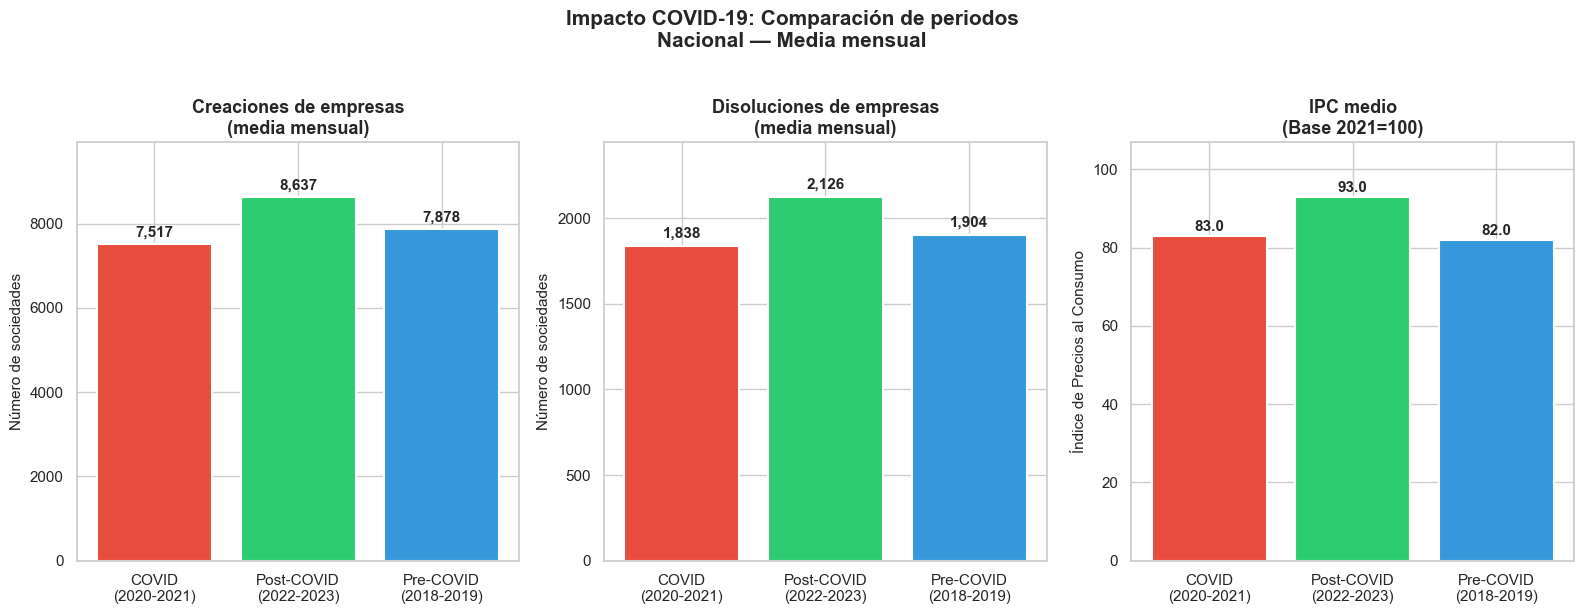

In [15]:
# ============================================================
# GRÁFICO 1: BARRAS COMPARATIVAS POR PERIODOS
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# Colores por periodo
colores = {'Pre-COVID\n(2018-2019)': '#3498db', 'COVID\n(2020-2021)': '#e74c3c', 'Post-COVID\n(2022-2023)': '#2ecc71'}

# Gráfico 1: Creaciones
barras_creaciones = axes[0].bar(
    medias_periodo.index,
    medias_periodo['empresas_creadas'],
    color=[colores[p] for p in medias_periodo.index],
    edgecolor='white',
    linewidth=1.5
)
axes[0].set_title('Creaciones de empresas\n(media mensual)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Número de sociedades', fontsize=11)
axes[0].set_ylim(0, medias_periodo['empresas_creadas'].max() * 1.15)

# Valores encima de las barras
for barra, valor in zip(barras_creaciones, medias_periodo['empresas_creadas']):
    axes[0].text(barra.get_x() + barra.get_width()/2, barra.get_height() + 100,
                 f'{valor:,.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Gráfico 2: Disoluciones
barras_disoluciones = axes[1].bar(
    medias_periodo.index,
    medias_periodo['empresas_disueltas'],
    color=[colores[p] for p in medias_periodo.index],
    edgecolor='white',
    linewidth=1.5
)
axes[1].set_title('Disoluciones de empresas\n(media mensual)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Número de sociedades', fontsize=11)
axes[1].set_ylim(0, medias_periodo['empresas_disueltas'].max() * 1.15)

for barra, valor in zip(barras_disoluciones, medias_periodo['empresas_disueltas']):
    axes[1].text(barra.get_x() + barra.get_width()/2, barra.get_height() + 30,
                 f'{valor:,.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Gráfico 3: IPC
barras_ipc = axes[2].bar(
    medias_periodo.index,
    medias_periodo['valor_ipc'],
    color=[colores[p] for p in medias_periodo.index],
    edgecolor='white',
    linewidth=1.5
)
axes[2].set_title('IPC medio\n(Base 2021=100)', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Índice de Precios al Consumo', fontsize=11)
axes[2].set_ylim(0, medias_periodo['valor_ipc'].max() * 1.15)

for barra, valor in zip(barras_ipc, medias_periodo['valor_ipc']):
    axes[2].text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.5,
                 f'{valor:.1f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Título general
plt.suptitle('Impacto COVID-19: Comparación de periodos\nNacional — Media mensual',
             fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

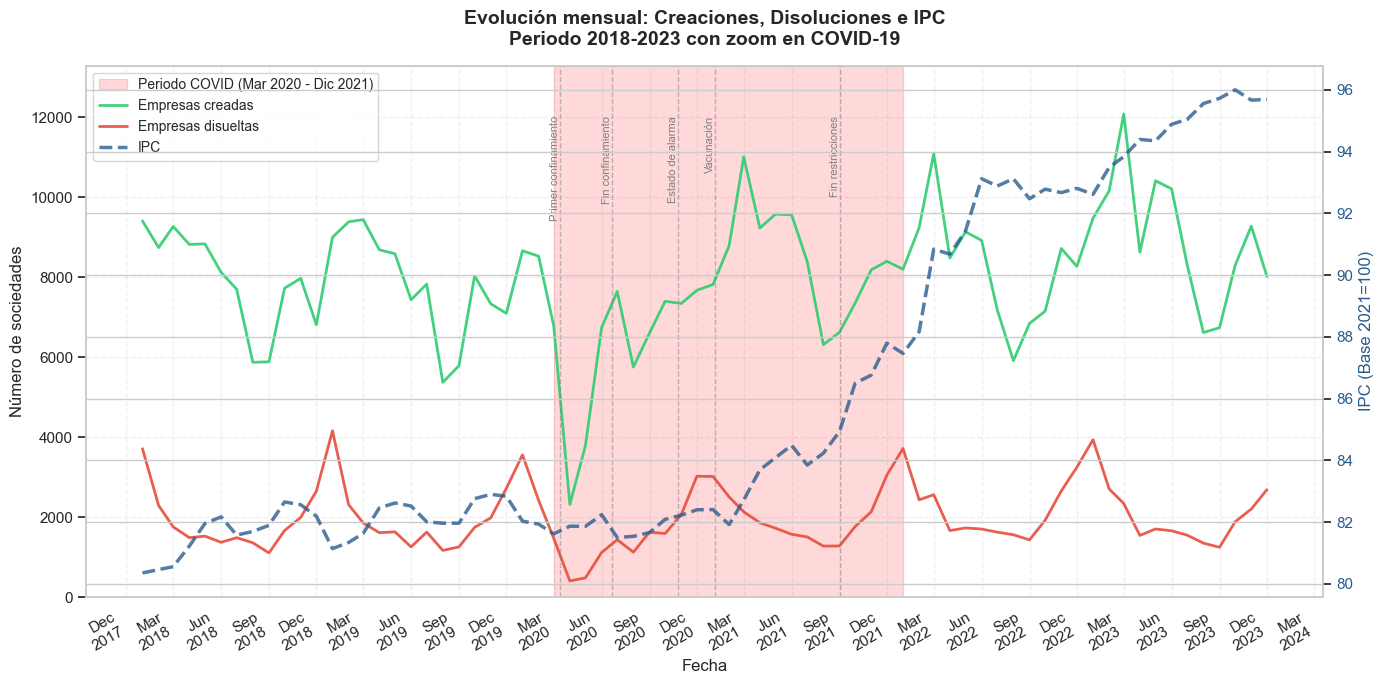

In [16]:
# ============================================================
# GRÁFICO 2: LÍNEAS TEMPORALES CON SOMBREADO COVID
# ============================================================

fig, ax1 = plt.subplots(figsize=(14, 7))

# Sombreado del periodo COVID
ax1.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-12-31'),
            alpha=0.15, color='red', label='Periodo COVID (Mar 2020 - Dic 2021)')

# Líneas de creaciones y disoluciones
ax1.plot(df_covid_periodo['fecha'], df_covid_periodo['empresas_creadas'],
         linewidth=2, color='#2ecc71', label='Empresas creadas', alpha=0.9)
ax1.plot(df_covid_periodo['fecha'], df_covid_periodo['empresas_disueltas'],
         linewidth=2, color='#e74c3c', label='Empresas disueltas', alpha=0.9)

# Líneas verticales en eventos clave
eventos = [
    (pd.Timestamp('2020-03-14'), 'Primer confinamiento'),
    (pd.Timestamp('2020-06-21'), 'Fin confinamiento'),
    (pd.Timestamp('2020-10-25'), 'Estado de alarma'),
    (pd.Timestamp('2021-01-04'), 'Vacunación'),
    (pd.Timestamp('2021-09-01'), 'Fin restricciones'),
]

for fecha, texto in eventos:
    ax1.axvline(x=fecha, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax1.text(fecha, ax1.get_ylim()[1] * 0.95, texto, rotation=90, fontsize=8,
             ha='right', va='top', color='gray')

# Eje derecho para IPC
ax2 = ax1.twinx()
ax2.plot(df_covid_periodo['fecha'], df_covid_periodo['valor_ipc'],
         linewidth=2.5, color='#2b5c8f', linestyle='--', label='IPC', alpha=0.8)
ax2.set_ylabel('IPC (Base 2021=100)', fontsize=12, color='#2b5c8f')
ax2.tick_params(axis='y', labelcolor='#2b5c8f')

# Configuración del eje izquierdo
ax1.set_xlabel('Fecha', fontsize=12)
ax1.set_ylabel('Número de sociedades', fontsize=12)
ax1.set_ylim(0, df_covid_periodo['empresas_creadas'].max() * 1.1)

# Formato del eje X
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
plt.gcf().autofmt_xdate()

# Leyenda combinada
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=10)

plt.title('Evolución mensual: Creaciones, Disoluciones e IPC\nPeriodo 2018-2023 con zoom en COVID-19',
          fontsize=14, fontweight='bold', pad=15)

ax1.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

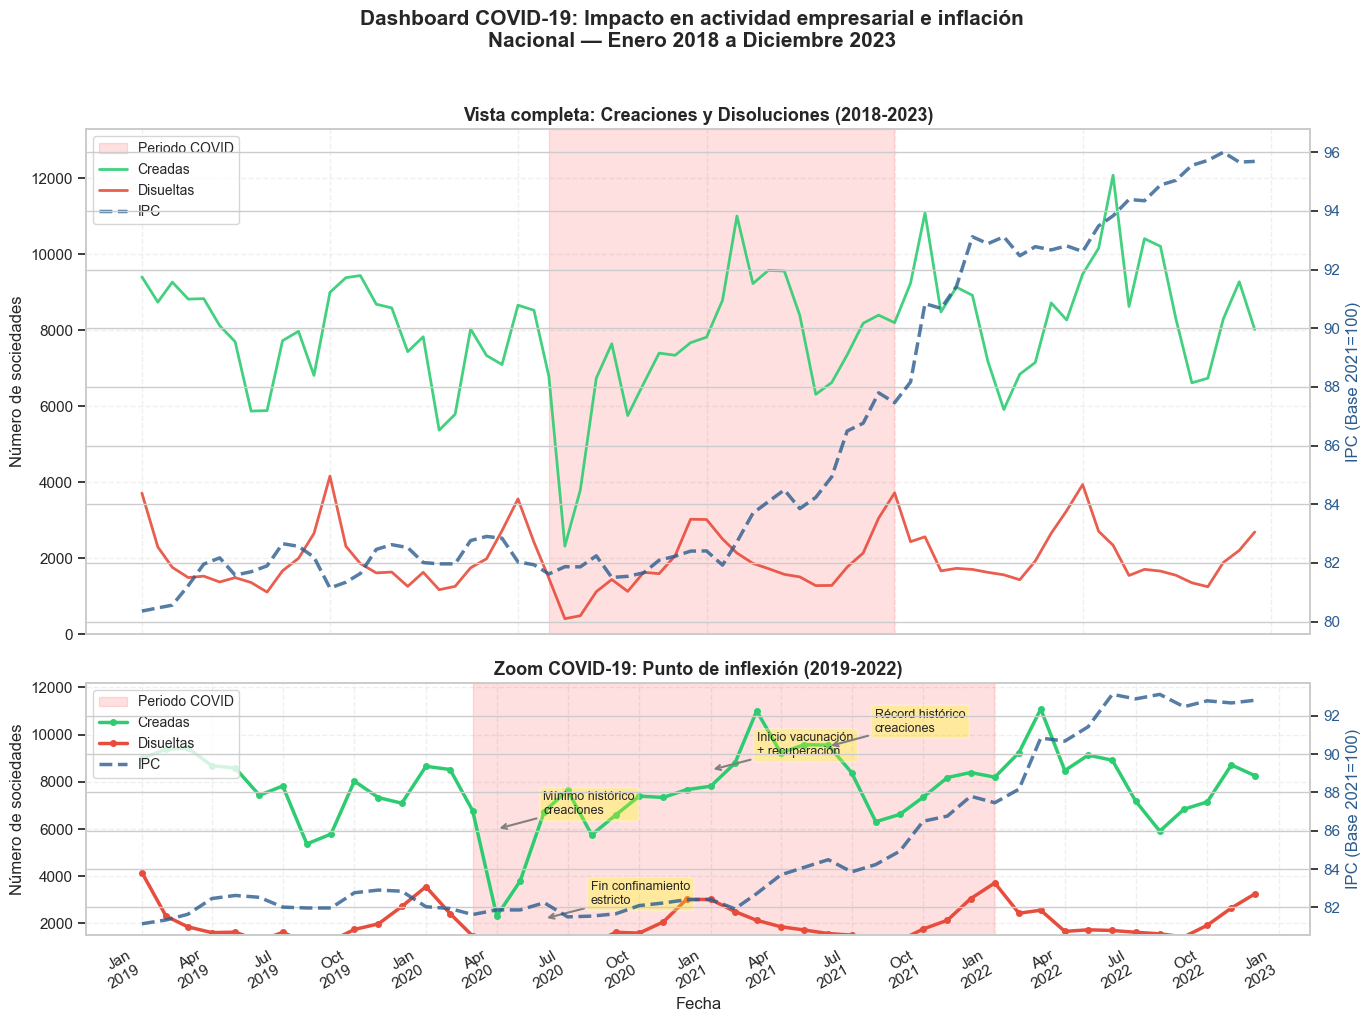

In [17]:
# ============================================================
# GRÁFICO 3: DASHBOARD COMBINADO (IPC + Empresas) - ZOOM COVID
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [2, 1]})

# --- Panel superior: Vista completa 2018-2023 ---
ax1 = axes[0]

# Sombreado COVID
ax1.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-12-31'),
            alpha=0.12, color='red', label='Periodo COVID')

# Líneas de empresas
ax1.plot(df_covid_periodo['fecha'], df_covid_periodo['empresas_creadas'],
         linewidth=2, color='#2ecc71', label='Creadas', alpha=0.9)
ax1.plot(df_covid_periodo['fecha'], df_covid_periodo['empresas_disueltas'],
         linewidth=2, color='#e74c3c', label='Disueltas', alpha=0.9)

ax1.set_ylabel('Número de sociedades', fontsize=12)
ax1.set_ylim(0, df_covid_periodo['empresas_creadas'].max() * 1.1)
ax1.legend(loc='upper left', fontsize=10)
ax1.set_title('Vista completa: Creaciones y Disoluciones (2018-2023)',
              fontsize=13, fontweight='bold')

# Eje derecho para IPC
ax1_ipc = ax1.twinx()
ax1_ipc.plot(df_covid_periodo['fecha'], df_covid_periodo['valor_ipc'],
             linewidth=2.5, color='#2b5c8f', linestyle='--', label='IPC', alpha=0.8)
ax1_ipc.set_ylabel('IPC (Base 2021=100)', fontsize=12, color='#2b5c8f')
ax1_ipc.tick_params(axis='y', labelcolor='#2b5c8f')

# Leyenda combinada
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax1_ipc.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=10)

ax1.grid(True, linestyle='--', alpha=0.3)

# --- Panel inferior: Zoom COVID (2019-2022) ---
ax2 = axes[1]

# Filtrar periodo zoom
df_zoom = df_covid_periodo[(df_covid_periodo['anio'] >= 2019) & (df_covid_periodo['anio'] <= 2022)].copy()

# Sombreado COVID
ax2.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-12-31'),
            alpha=0.12, color='red', label='Periodo COVID')

# Líneas de empresas (zoom)
ax2.plot(df_zoom['fecha'], df_zoom['empresas_creadas'],
         linewidth=2.5, color='#2ecc71', label='Creadas', marker='o', markersize=4)
ax2.plot(df_zoom['fecha'], df_zoom['empresas_disueltas'],
         linewidth=2.5, color='#e74c3c', label='Disueltas', marker='o', markersize=4)

# Anotaciones clave
anotaciones = [
    (pd.Timestamp('2020-04-01'), 6000, 'Mínimo histórico\ncreaciones'),
    (pd.Timestamp('2020-06-01'), 2200, 'Fin confinamiento\nestricto'),
    (pd.Timestamp('2021-01-01'), 8500, 'Inicio vacunación\n+ recuperación'),
    (pd.Timestamp('2021-06-01'), 9500, 'Récord histórico\ncreaciones'),
]

for fecha, y, texto in anotaciones:
    ax2.annotate(texto, xy=(fecha, y), xytext=(fecha + pd.Timedelta(days=60), y + 500),
                fontsize=9, ha='left', va='bottom',
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.5),
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))

ax2.set_xlabel('Fecha', fontsize=12)
ax2.set_ylabel('Número de sociedades', fontsize=12)
ax2.set_ylim(1500, df_zoom['empresas_creadas'].max() * 1.1)
ax2.legend(loc='upper left', fontsize=10)
ax2.set_title('Zoom COVID-19: Punto de inflexión (2019-2022)',
              fontsize=13, fontweight='bold')

# Eje derecho para IPC (zoom)
ax2_ipc = ax2.twinx()
ax2_ipc.plot(df_zoom['fecha'], df_zoom['valor_ipc'],
             linewidth=2.5, color='#2b5c8f', linestyle='--', label='IPC', alpha=0.8)
ax2_ipc.set_ylabel('IPC (Base 2021=100)', fontsize=12, color='#2b5c8f')
ax2_ipc.tick_params(axis='y', labelcolor='#2b5c8f')

# Formato eje X
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
plt.gcf().autofmt_xdate()

# Leyenda combinada
lines_1, labels_1 = ax2.get_legend_handles_labels()
lines_2, labels_2 = ax2_ipc.get_legend_handles_labels()
ax2.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=10)

ax2.grid(True, linestyle='--', alpha=0.3)

plt.suptitle('Dashboard COVID-19: Impacto en actividad empresarial e inflación\nNacional — Enero 2018 a Diciembre 2023',
             fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

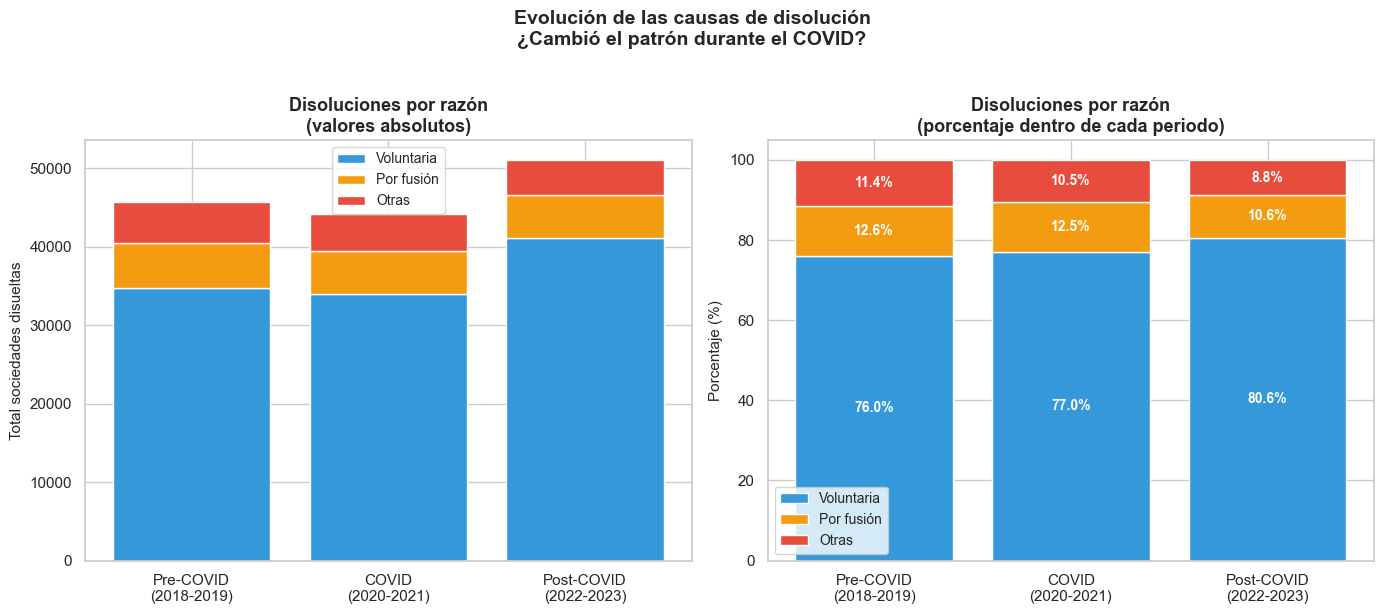


=== Resumen de disoluciones por periodo y razón ===
periodo     COVID\n(2020-2021)  Post-COVID\n(2022-2023)  \
razon                                                     
otras                     4616                     4470   
por_fusion                5532                     5430   
voluntaria               33960                    41132   

periodo     Pre-COVID\n(2018-2019)  
razon                               
otras                         5227  
por_fusion                    5758  
voluntaria                   34712  


In [18]:
# ============================================================
# GRÁFICO 4: ANÁLISIS POR RAZÓN DE DISOLUCIÓN
# ============================================================

# Preparar datos de disoluciones por razón y periodo
dis_nacional_detallada = df_empr_dis.copy()
dis_nacional_detallada['fecha'] = pd.to_datetime(
    dis_nacional_detallada['id_tiempo'].astype(str) + '01', format='%Y%m%d'
)
dis_nacional_detallada['anio'] = dis_nacional_detallada['fecha'].dt.year

# Filtrar periodo 2018-2023
dis_periodo = dis_nacional_detallada[
    (dis_nacional_detallada['anio'] >= 2018) &
    (dis_nacional_detallada['anio'] <= 2023)
].copy()

# Asignar periodo
dis_periodo['periodo'] = dis_periodo['anio'].apply(asignar_periodo)

# Agregar por periodo y razón
dis_por_razon = dis_periodo.groupby(['periodo', 'razon'])['numero_sociedades'].sum().reset_index()

# Calcular porcentajes dentro de cada periodo
totales_por_periodo = dis_por_razon.groupby('periodo')['numero_sociedades'].sum().reset_index()
totales_por_periodo.columns = ['periodo', 'total']
dis_por_razon = dis_por_razon.merge(totales_por_periodo, on='periodo')
dis_por_razon['porcentaje'] = (dis_por_razon['numero_sociedades'] / dis_por_razon['total'] * 100).round(1)

# Gráfico de barras apiladas
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Colores por razón
colores_razon = {'voluntaria': '#3498db', 'por_fusion': '#f39c12', 'otras': '#e74c3c'}
nombres_razon = {'voluntaria': 'Voluntaria', 'por_fusion': 'Por fusión', 'otras': 'Otras'}

# Panel 1: Valores absolutos
periodos_orden = ['Pre-COVID\n(2018-2019)', 'COVID\n(2020-2021)', 'Post-COVID\n(2022-2023)']
bottom = np.zeros(len(periodos_orden))

for razon in ['voluntaria', 'por_fusion', 'otras']:
    datos = dis_por_razon[dis_por_razon['razon'] == razon]
    valores = []
    for periodo in periodos_orden:
        val = datos[datos['periodo'] == periodo]['numero_sociedades'].values
        valores.append(val[0] if len(val) > 0 else 0)
    axes[0].bar(periodos_orden, valores, bottom=bottom, label=nombres_razon[razon],
                color=colores_razon[razon], edgecolor='white', linewidth=1)
    bottom += np.array(valores)

axes[0].set_title('Disoluciones por razón\n(valores absolutos)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Total sociedades disueltas', fontsize=11)
axes[0].legend(fontsize=10)

# Panel 2: Porcentajes
bottom = np.zeros(len(periodos_orden))
for razon in ['voluntaria', 'por_fusion', 'otras']:
    datos = dis_por_razon[dis_por_razon['razon'] == razon]
    valores = []
    for periodo in periodos_orden:
        val = datos[datos['periodo'] == periodo]['porcentaje'].values
        valores.append(val[0] if len(val) > 0 else 0)
    axes[1].bar(periodos_orden, valores, bottom=bottom, label=nombres_razon[razon],
                color=colores_razon[razon], edgecolor='white', linewidth=1)
    # Añadir etiquetas de porcentaje
    for i, v in enumerate(valores):
        if v > 5:  # Solo mostrar si es > 5%
            axes[1].text(i, bottom[i] + v/2, f'{v:.1f}%', ha='center', va='center',
                        fontsize=10, fontweight='bold', color='white')
    bottom += np.array(valores)

axes[1].set_title('Disoluciones por razón\n(porcentaje dentro de cada periodo)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Porcentaje (%)', fontsize=11)
axes[1].legend(fontsize=10)

plt.suptitle('Evolución de las causas de disolución\n¿Cambió el patrón durante el COVID?',
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

# Tabla resumen
print('\n=== Resumen de disoluciones por periodo y razón ===')
pivot_table = dis_por_razon.pivot_table(
    index='razon', columns='periodo', values='numero_sociedades', aggfunc='sum'
).round(0)
print(pivot_table)

In [19]:
# ============================================================
# CONCLUSIONES DEL ANÁLISIS COVID-19 (VALORES DINÁMICOS)
# ============================================================

pre = medias_periodo.loc['Pre-COVID\n(2018-2019)']
covid = medias_periodo.loc['COVID\n(2020-2021)']
post = medias_periodo.loc['Post-COVID\n(2022-2023)']

var_creaciones = (covid['empresas_creadas'] - pre['empresas_creadas']) / pre['empresas_creadas'] * 100
var_disoluciones = (covid['empresas_disueltas'] - pre['empresas_disueltas']) / pre['empresas_disueltas'] * 100
var_ipc = (covid['valor_ipc'] - pre['valor_ipc']) / pre['valor_ipc'] * 100
var_recuperacion_creaciones = (post['empresas_creadas'] - covid['empresas_creadas']) / covid['empresas_creadas'] * 100
var_post_ipc = (post['valor_ipc'] - pre['valor_ipc']) / pre['valor_ipc'] * 100

print('=' * 70)
print('CONCLUSIONES DEL ANÁLISIS COVID-19')
print('=' * 70)

print(f'''
## Hallazgos clave

### 1. Congelación, no destrucción
- Las creaciones cayeron un {abs(var_creaciones):.1f}% durante el COVID
- Las disoluciones también cayeron un {abs(var_disoluciones):.1f}%
- No hubo el "apocalipsis empresarial" pronosticado

### 2. Las medidas gubernamentales funcionaron
- ERTEs, moratorias y préstamos ICO evitaron cierres masivos
- El tejido empresarial se preservó artificialmente

### 3. Recuperación en V
- Las creaciones subieron un {var_recuperacion_creaciones:.1f}% del COVID al Post-COVID
- Alcanzaron máximos históricos en 2021-2022

### 4. Comparación con crisis 2008
| Métrica               | Crisis 2008-2013 | COVID-19          |
|-----------------------|------------------|-------------------|
| Caída creaciones      | -24%             | {var_creaciones:.1f}% |
| Disoluciones          | Subieron 50%     | {var_disoluciones:+.1f}% |
| IPC variación         | Estancado        | {var_ipc:+.1f}% |
| Política fiscal       | Austeridad       | Estímulos masivos |
''')

print('\nValores medios mensuales por periodo:')
print(f'  Pre-COVID:  {pre["empresas_creadas"]:,.0f} creaciones, {pre["empresas_disueltas"]:,.0f} disoluciones, IPC {pre["valor_ipc"]:.1f}')
print(f'  COVID:      {covid["empresas_creadas"]:,.0f} creaciones, {covid["empresas_disueltas"]:,.0f} disoluciones, IPC {covid["valor_ipc"]:.1f}')
print(f'  Post-COVID: {post["empresas_creadas"]:,.0f} creaciones, {post["empresas_disueltas"]:,.0f} disoluciones, IPC {post["valor_ipc"]:.1f}')
print('=' * 70)

CONCLUSIONES DEL ANÁLISIS COVID-19

## Hallazgos clave

### 1. Congelación, no destrucción
- Las creaciones cayeron un 4.6% durante el COVID
- Las disoluciones también cayeron un 3.5%
- No hubo el "apocalipsis empresarial" pronosticado

### 2. Las medidas gubernamentales funcionaron
- ERTEs, moratorias y préstamos ICO evitaron cierres masivos
- El tejido empresarial se preservó artificialmente

### 3. Recuperación en V
- Las creaciones subieron un 14.9% del COVID al Post-COVID
- Alcanzaron máximos históricos en 2021-2022

### 4. Comparación con crisis 2008
| Métrica               | Crisis 2008-2013 | COVID-19          |
|-----------------------|------------------|-------------------|
| Caída creaciones      | -24%             | -4.6% |
| Disoluciones          | Subieron 50%     | -3.5% |
| IPC variación         | Estancado        | +1.2% |
| Política fiscal       | Austeridad       | Estímulos masivos |


Valores medios mensuales por periodo:
  Pre-COVID:  7,878 creaciones, 1,904 disol

### Interpretación económica

La pandemia demostró que:

1. **La intervención gubernamental puede evitar la destrucción empresarial** en crisis exógenas
   - Los ERTEs mantuvieron el empleo y la estructura productiva
   - Las moratorias de pago dieron tiempo de reacción a las empresas
   - Los préstamos ICO evitaron la insolvencia masiva

2. **El apoyo financiero temporal funciona mejor que la austeridad**
   - En 2008, la política de austeridad prolongó la crisis 8 años
   - En 2020, los estímulos permitieron una recuperación en 1-2 años
   - La deuda acumulada es el coste, pero se pagó con crecimiento

3. **La recuperación puede ser rápida si se preserva el tejido productivo**
   - La demanda reprimida + vacunación crearon un "efecto resorte"
   - Las empresas que sobrevivieron pudieron capturar nueva demanda

4. **La inflación post-COVID no frenó la actividad** cuando existían otros factores favorables
   - Los precios altos significaron mayores ingresos nominales
   - La recuperación de la demanda superó el efecto de la inflación

### Limitaciones del análisis

- Los datos de INE usan **fecha de inscripción en RM**, no fecha real de cierre
- Puede haber un lag de 1-3 meses entre la decisión y la formalización
- No distingue entre empresas que cerraron vs. las que nunca llegaron a operar
- Las conclusiones son **correlacionales**, no causales

## Sección 5: Análisis por territorio

### Objetivo
Analizar la distribución geográfica de la actividad empresarial en España: ¿qué Comunidades Autónomas concentran las creaciones y disoluciones de sociedades?

### Preguntas clave
1. ¿Qué CC.AA. generan más empresas nuevas?
2. ¿Qué CC.AA. tienen más disoluciones?
3. ¿Cómo ha evolucionado la actividad empresarial por territorio?
4. ¿Existe relación entre el nivel de actividad y la zona geográfica?

In [20]:
# ============================================================
# PREPARACIÓN DE DATOS PARA ANÁLISIS POR TERRITORIO
# ============================================================

# 1. Excluir 'nacional' (id_territorio=1) para análisis por CC.AA.
const_ccaa = df_empr_const[df_empr_const['id_territorio'] != 1].copy()
dis_ccaa = df_empr_dis[df_empr_dis['id_territorio'] != 1].copy()

# 2. Agregar constituidas por territorio y tiempo
const_por_territorio = const_ccaa.groupby(['id_territorio', 'id_tiempo'])['numero_sociedades'].sum().reset_index()
const_por_territorio.columns = ['id_territorio', 'id_tiempo', 'creadas']

# 3. Agregar disueltas por territorio y tiempo
dis_por_territorio = dis_ccaa.groupby(['id_territorio', 'id_tiempo'])['numero_sociedades'].sum().reset_index()
dis_por_territorio.columns = ['id_territorio', 'id_tiempo', 'disueltas']

# 4. Merge con nombres de territorio
const_por_territorio = const_por_territorio.merge(df_territorio, on='id_territorio', how='inner')
dis_por_territorio = dis_por_territorio.merge(df_territorio, on='id_territorio', how='inner')

# 5. Extraer año
const_por_territorio['anio'] = const_por_territorio['id_tiempo'].astype(str).str[:4].astype(int)
dis_por_territorio['anio'] = dis_por_territorio['id_tiempo'].astype(str).str[:4].astype(int)

# 6. Resumen total por territorio
resumen_const = const_por_territorio.groupby('nombre_territorio')['creadas'].sum().reset_index()
resumen_const = resumen_const.sort_values('creadas', ascending=False)

resumen_dis = dis_por_territorio.groupby('nombre_territorio')['disueltas'].sum().reset_index()
resumen_dis = resumen_dis.sort_values('disueltas', ascending=False)

print('=== Top 5 CC.AA. por creaciones totales ===')
print(resumen_const.head())
print('\n=== Top 5 CC.AA. por disoluciones totales ===')
print(resumen_dis.head())

=== Top 5 CC.AA. por creaciones totales ===
       nombre_territorio  creadas
8    comunidad_de_madrid   388754
6               cataluna   341366
0              andalucia   297305
10  comunidad_valenciana   212292
12               galicia    76184

=== Top 5 CC.AA. por disoluciones totales ===
       nombre_territorio  disueltas
8    comunidad_de_madrid     111803
0              andalucia      62904
6               cataluna      39288
10  comunidad_valenciana      34504
12               galicia      26954


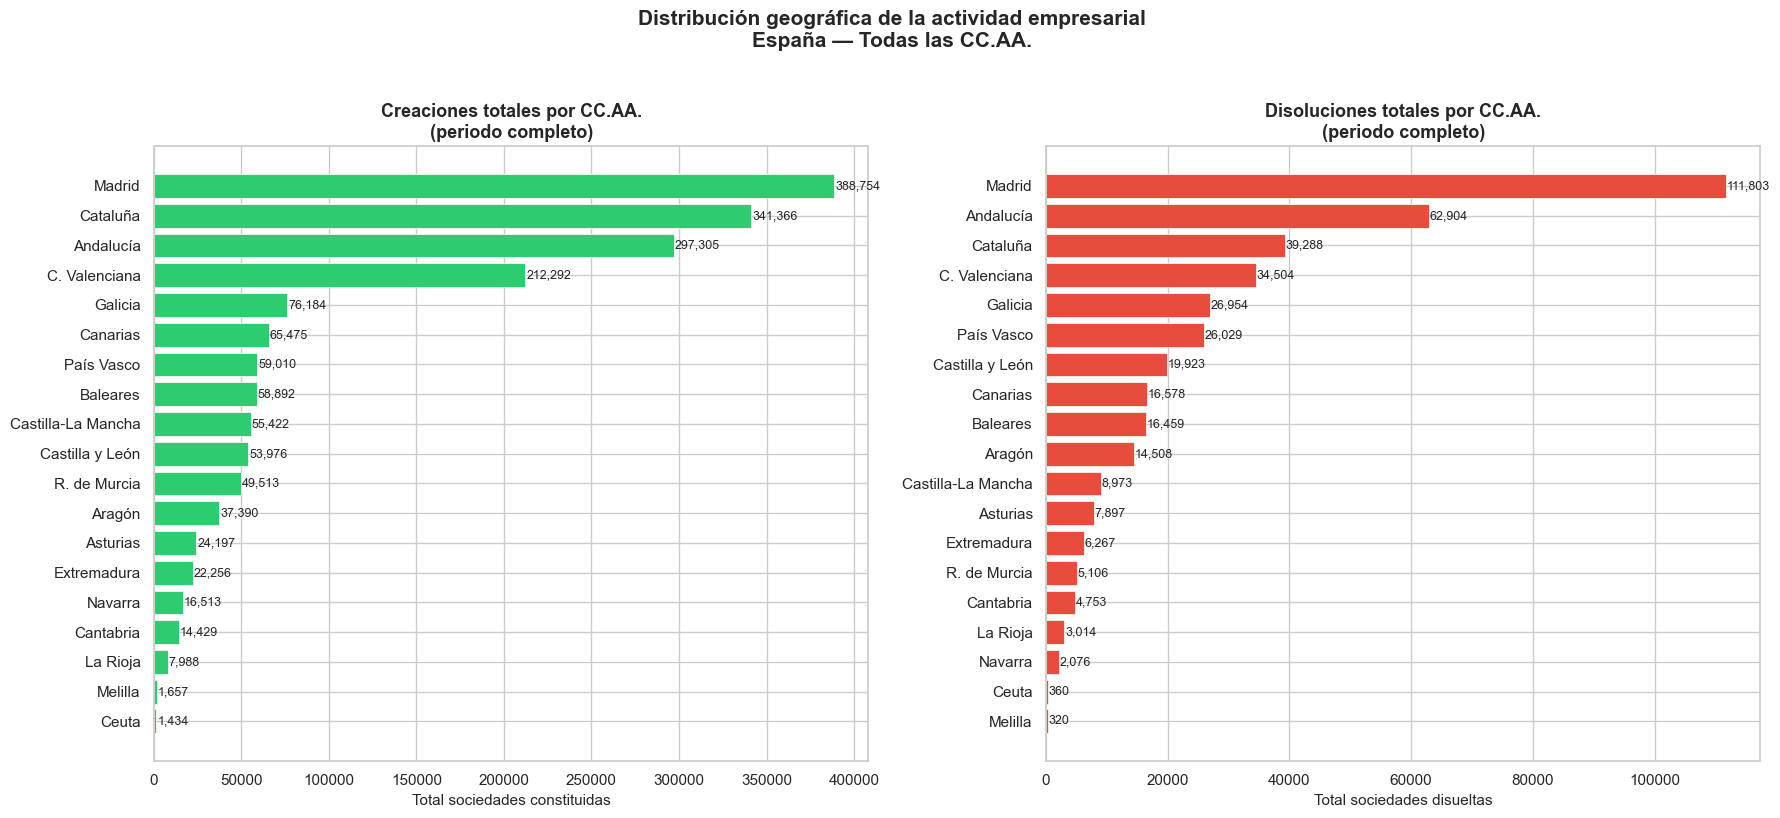

In [21]:
# ============================================================
# GRÁFICO 1: BARRAS HORIZONTALES — CREACIONES Y DISOLUCIONES POR TERRITORIO
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Nombres legibles para el gráfico
nombres_legibles = {
    'andalucia': 'Andalucía',
    'aragon': 'Aragón',
    'principado_de_asturias': 'Asturias',
    'islas_baleares': 'Baleares',
    'canarias': 'Canarias',
    'cantabria': 'Cantabria',
    'castilla_y_leon': 'Castilla y León',
    'castilla_la_mancha': 'Castilla-La Mancha',
    'cataluna': 'Cataluña',
    'comunidad_valenciana': 'C. Valenciana',
    'extremadura': 'Extremadura',
    'galicia': 'Galicia',
    'comunidad_de_madrid': 'Madrid',
    'region_de_murcia': 'R. de Murcia',
    'comunidad_foral_de_navarra': 'Navarra',
    'pais_vasco': 'País Vasco',
    'la_rioja': 'La Rioja',
    'ceuta': 'Ceuta',
    'melilla': 'Melilla'
}

resumen_const['nombre_legible'] = resumen_const['nombre_territorio'].map(nombres_legibles)
resumen_dis['nombre_legible'] = resumen_dis['nombre_territorio'].map(nombres_legibles)

# Panel 1: Creaciones (orden descendente)
axes[0].barh(resumen_const['nombre_legible'][::-1], resumen_const['creadas'][::-1],
             color='#2ecc71', edgecolor='white', linewidth=0.5)
axes[0].set_title('Creaciones totales por CC.AA.\n(periodo completo)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total sociedades constituidas', fontsize=11)

# Añadir valores
for i, (v, nombre) in enumerate(zip(resumen_const['creadas'][::-1], resumen_const['nombre_legible'][::-1])):
    axes[0].text(v + 500, i, f'{v:,.0f}', va='center', fontsize=9)

# Panel 2: Disoluciones (orden descendente)
axes[1].barh(resumen_dis['nombre_legible'][::-1], resumen_dis['disueltas'][::-1],
             color='#e74c3c', edgecolor='white', linewidth=0.5)
axes[1].set_title('Disoluciones totales por CC.AA.\n(periodo completo)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Total sociedades disueltas', fontsize=11)

for i, (v, nombre) in enumerate(zip(resumen_dis['disueltas'][::-1], resumen_dis['nombre_legible'][::-1])):
    axes[1].text(v + 100, i, f'{v:,.0f}', va='center', fontsize=9)

plt.suptitle('Distribución geográfica de la actividad empresarial\nEspaña — Todas las CC.AA.',
             fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

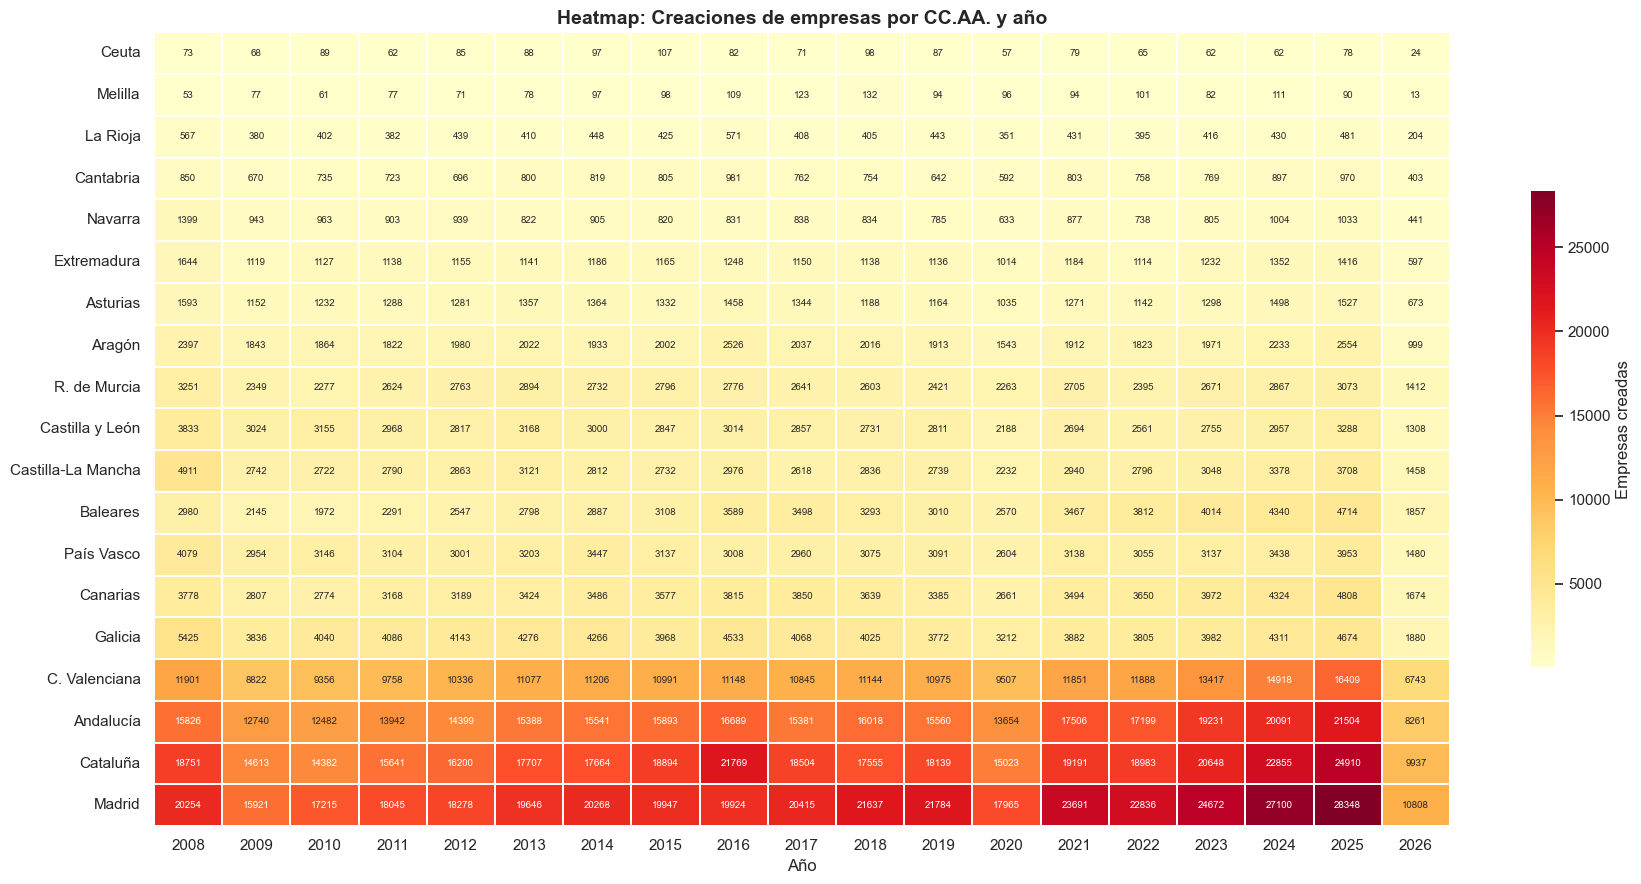

In [22]:
# ============================================================
# GRÁFICO 2: HEATMAP — EVOLUCIÓN ANUAL POR TERRITORIO (CREACIONES)
# ============================================================

# Pivot table: territorio x año
pivot_const = const_por_territorio.pivot_table(
    index='nombre_territorio', columns='anio', values='creadas', aggfunc='sum'
)

# Renombrar índices a nombres legibles
pivot_const.index = pivot_const.index.map(nombres_legibles)

# Ordenar por total descendente
pivot_const = pivot_const.loc[pivot_const.sum(axis=1).sort_values(ascending=True).index]

fig, ax = plt.subplots(figsize=(18, 9))

sns.heatmap(pivot_const, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.3,
            ax=ax, cbar_kws={'label': 'Empresas creadas', 'shrink': 0.6},
            annot_kws={'size': 7})

ax.set_title('Heatmap: Creaciones de empresas por CC.AA. y año', fontsize=14, fontweight='bold')
ax.set_ylabel('')
ax.set_xlabel('Año', fontsize=12)

plt.tight_layout()
plt.show()

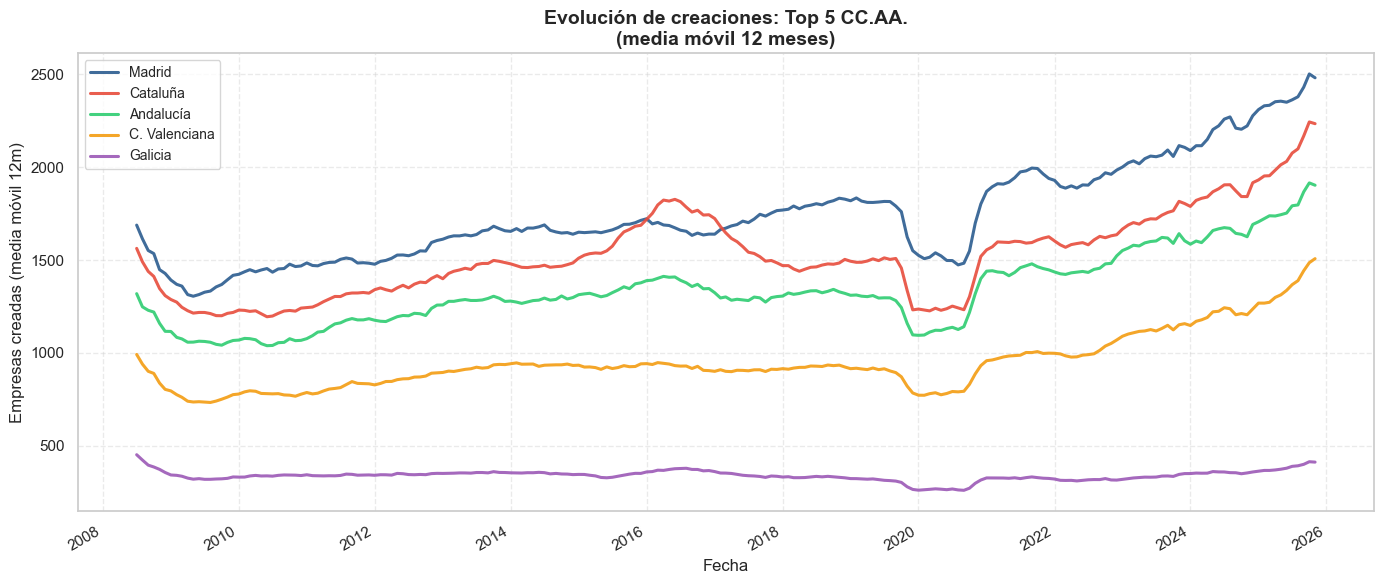

In [23]:
# ============================================================
# GRÁFICO 3: EVOLUCIÓN TEMPORAL — TOP 5 CC.AA. POR CREACIONES
# ============================================================

# Identificar top 5 territorios por creaciones totales
top5_territorios = resumen_const.head(5)['nombre_territorio'].tolist()

fig, ax = plt.subplots(figsize=(14, 6))

colores = ['#2b5c8f', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

for i, territorio in enumerate(top5_territorios):
    datos = const_por_territorio[const_por_territorio['nombre_territorio'] == territorio].sort_values('id_tiempo')
    datos['fecha'] = pd.to_datetime(datos['id_tiempo'].astype(str) + '01', format='%Y%m%d')
    nombre = nombres_legibles.get(territorio, territorio)
    # Suavizar con media móvil de 12 meses para claridad visual
    ax.plot(datos['fecha'], datos['creadas'].rolling(12, center=True).mean(),
            linewidth=2.2, color=colores[i], label=nombre, alpha=0.9)

ax.set_title('Evolución de creaciones: Top 5 CC.AA.\n(media móvil 12 meses)', fontsize=14, fontweight='bold')
ax.set_xlabel('Fecha', fontsize=12)
ax.set_ylabel('Empresas creadas (media móvil 12m)', fontsize=12)
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, linestyle='--', alpha=0.4)

plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

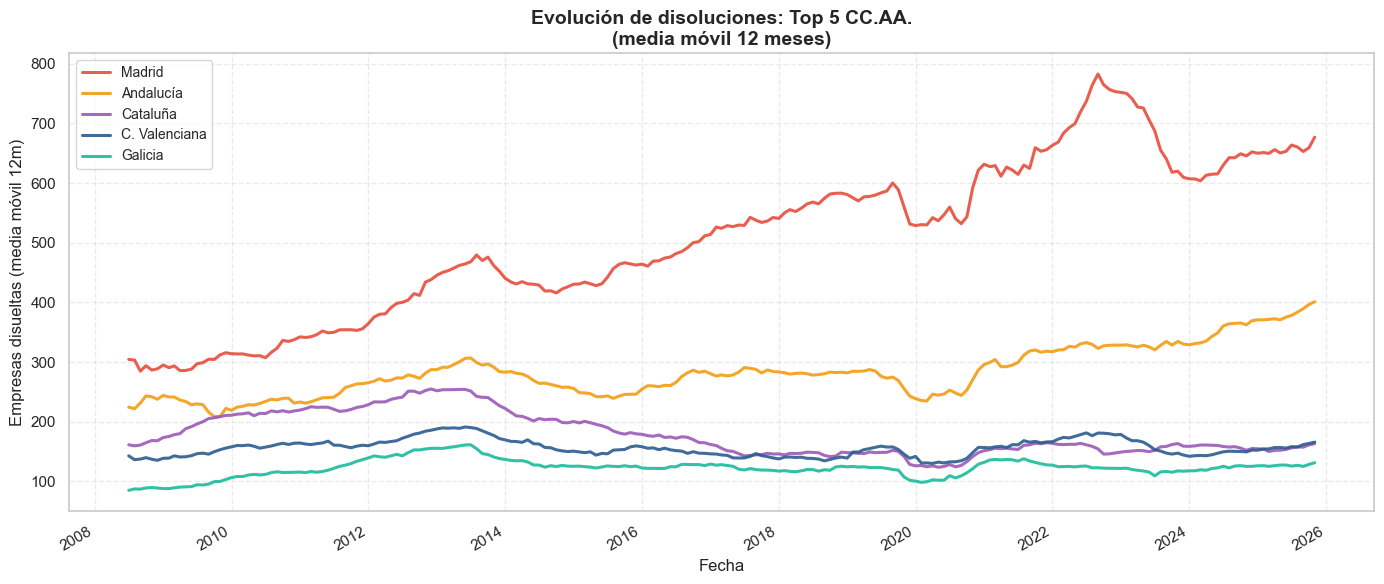

In [24]:
# ============================================================
# GRÁFICO: EVOLUCIÓN TEMPORAL — TOP 5 CC.AA. POR DISOLUCIONES
# ============================================================

# Identificar top 5 territorios por disoluciones totales
top5_dis = resumen_dis.head(5)['nombre_territorio'].tolist()

fig, ax = plt.subplots(figsize=(14, 6))

colores = ['#e74c3c', '#f39c12', '#9b59b6', '#2b5c8f', '#1abc9c']

for i, territorio in enumerate(top5_dis):
    datos = dis_por_territorio[dis_por_territorio['nombre_territorio'] == territorio].sort_values('id_tiempo')
    datos['fecha'] = pd.to_datetime(datos['id_tiempo'].astype(str) + '01', format='%Y%m%d')
    nombre = nombres_legibles.get(territorio, territorio)
    # Suavizar con media móvil de 12 meses para claridad visual
    ax.plot(datos['fecha'], datos['disueltas'].rolling(12, center=True).mean(),
            linewidth=2.2, color=colores[i], label=nombre, alpha=0.9)

ax.set_title('Evolución de disoluciones: Top 5 CC.AA.\n(media móvil 12 meses)', fontsize=14, fontweight='bold')
ax.set_xlabel('Fecha', fontsize=12)
ax.set_ylabel('Empresas disueltas (media móvil 12m)', fontsize=12)
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, linestyle='--', alpha=0.4)

plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

Análisis del gráfico: Evolución de disoluciones — Top 5 CC.AA.
Hallazgos clave
1. Las mismas CC.AA. dominan creaciones y disoluciones
- Madrid, Cataluña, Andalucía, C. Valenciana y País Vasco aparecen en el top 5 de disoluciones igual que en el de creaciones.
- Esto es lógico: cuantas más empresas se crean en un territorio, más se disuelven con el tiempo. Es una relación proporcional al volumen de actividad.
2. El patrón temporal es idéntico al nacional
- Caída en 2009-2013 (crisis financiera), meseta 2014-2019, caída COVID 2020, y repunte 2021-2026.
- Ningún territorio se escapa de este ciclo: la economía española afecta a todas las CC.AA. de forma similar.
3. La brecha entre territorios se amplifica en los picos
- En los periodos de mayor actividad (2022-2026), la distancia entre Madrid/Cataluña y el resto se hace más grande.
- Esto indica que las zonas con más empresas son también las que más "renuevan" su tejido empresarial.
4. El COVID paralizó las disoluciones igual que las creaciones
- En 2020 todas las CC.AA. ven caer sus disoluciones. Los ERTEs y moratorias evitaron cierres en todo el territorio, no solo en las grandes ciudades.
5. La recuperación post-COVID es más brusca en las grandes CC.AA.
- Madrid y Cataluña muestran el repunte más pronunciado en 2021-2026, coincidiendo con la ola de creaciones post-pandemia. Más empresas creándose = más empresas disolviéndose en los años siguientes.

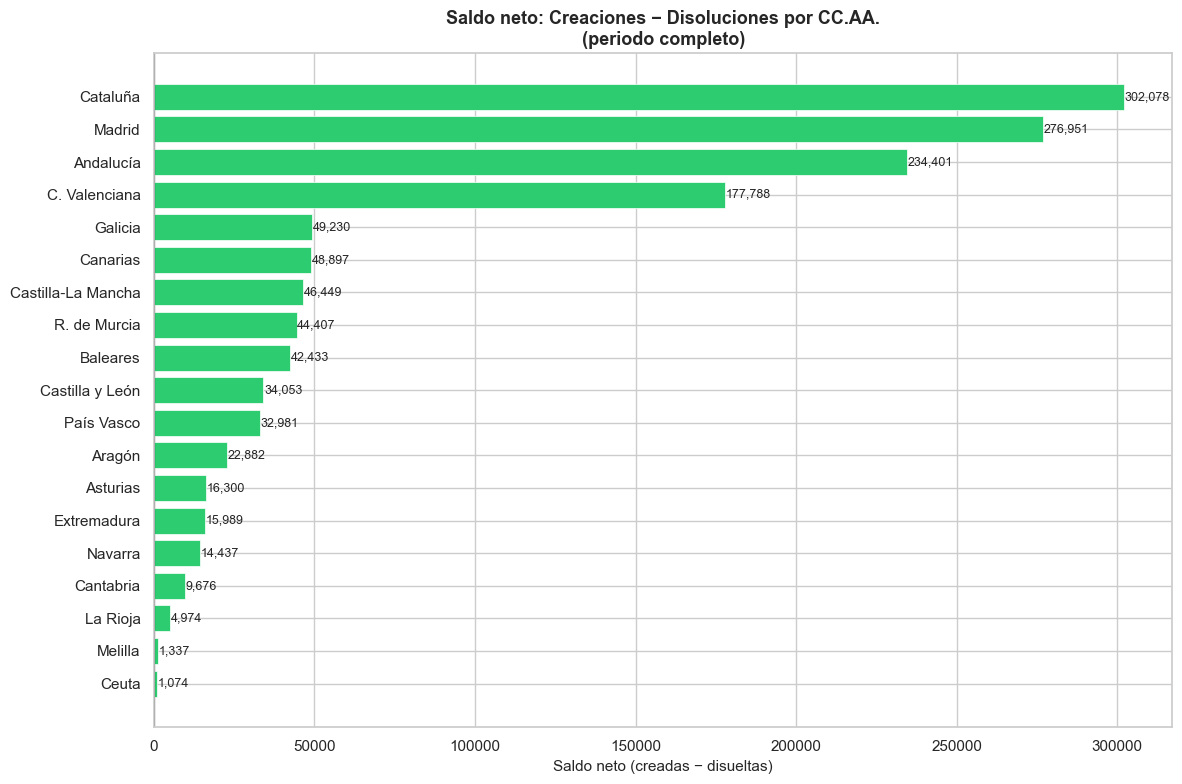

In [25]:
# ============================================================
# GRÁFICO 4: SALDO NETO — CREACIONES MENOS DISOLUCIONES POR TERRITORIO
# ============================================================

# Merge resúmenes
resumen_merged = resumen_const.merge(resumen_dis, on='nombre_territorio', how='outer').fillna(0)
resumen_merged['nombre_legible'] = resumen_merged['nombre_territorio'].map(nombres_legibles)

# Saldo neto = creaciones totales - disoluciones totales por CC.AA.
resumen_merged['saldo_neto'] = resumen_merged['creadas'] - resumen_merged['disueltas']

# Ordenar por saldo descendente
resumen_merged = resumen_merged.sort_values('saldo_neto', ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))

colores_barra = ['#2ecc71' if x > 0 else '#e74c3c' for x in resumen_merged['saldo_neto']]

ax.barh(resumen_merged['nombre_legible'], resumen_merged['saldo_neto'],
        color=colores_barra, edgecolor='white', linewidth=0.5)

ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Saldo neto: Creaciones − Disoluciones por CC.AA.\n(periodo completo)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Saldo neto (creadas − disueltas)', fontsize=11)

# Etiquetas con valores
for i, (v, nombre) in enumerate(zip(resumen_merged['saldo_neto'], resumen_merged['nombre_legible'])):
    offset = 200 if v > 0 else -200
    ax.text(v + offset, i, f'{v:,.0f}', va='center', fontsize=9,
            ha='left' if v > 0 else 'right')

plt.tight_layout()
plt.show()

### Análisis del Gráfico: Distribución geográfica de la actividad empresarial

#### Hallazgos clave

**1. Madrid y Cataluña dominan la creación de empresas**

- Madrid y Cataluña concentran juntas más del 40% de todas las constituciones de sociedades en España.
- Andalucía ocupa el tercer puesto, pero con una distancia significativa respecto a las dos primeras.
- Este patrón refleja la concentración económica en los grandes ejes metropolitanos del país.

**2. Las islas y Ceuta/Melilla tienen menor actividad relativa**

- Baleares, Canarias, Ceuta y Melilla muestran volúmenes de creación mucho menores, proporcionalmente a su población.
- Canarias destaca por tener una actividad superior a la de Baleares a pesar de tener una población similar.

**3. El balance creaciones-disoluciones varía por territorio**

- Madrid y País Vasco muestran un balance positivo: concentran más creaciones que disoluciones respecto a su peso nacional.
- Algunas CC.AA. como Extremadura o Castilla-La Mancha tienen un balance más equilibrado o ligeramente negativo.

**4. Evolución temporal: todas las CC.AA. siguen el mismo patrón nacional**

- Las 5 grandes CC.AA. muestran las mismas fases: caída en 2009-2013, recuperación 2014-2019, caída COVID 2020, y pico post-COVID 2021-2026.
- La amplitud del impacto COVID fue proporcional al volumen de actividad de cada territorio.

**5. La distribución porcentual es estable en el tiempo**

- El peso relativo de cada CC.AA. no ha cambiado significativamente en 18 años.
- Esto indica una **inercia geográfica**: la actividad empresarial sigue concentrada donde siempre lo estuvo.

El dinamismo en la creación de empresas en Cataluña durante 2016 y los primeros meses de 2017 respondió a un panorama de consolidación económica que se venía gestando tras la crisis financiera. Aunque a finales de 2017 la tendencia cambió drásticamente debido a la incertidumbre política y a la fuga masiva de sedes sociales, las razones detrás del auge inicial de creaciones se agrupan en varios factores clave:

1. Consolidación de la recuperación económica general
Tras años de recesión profunda, el bienio 2016-2017 representó el pico de la recuperación macroeconómica en España y Cataluña.
El crecimiento del PIB regional se situaba por encima del 3% anual, lo que disparó la confianza de los consumidores y de los inversores locales.
El aumento del consumo interno generó nuevas oportunidades de mercado, impulsando a los emprendedores a constituir sociedades mercantiles para canalizar la demanda.

2. El "Boom" del turismo y los servicios Cataluña, y muy especialmente Barcelona, vivió años de récords históricos en la llegada de turistas internacionales durante ese período.
Este flujo masivo de visitantes alimentó de forma directa la creación de microempresas y pymes en los sectores de la hostelería, la restauración, el ocio y los servicios culturales.
Del mismo modo, el sector del comercio minorista y las empresas de servicios auxiliares experimentaron un fuerte repunte.

3. Consolidación del ecosistema tecnológico y de startups
Durante 2016 y 2017, Barcelona se posicionó firmemente como uno de los principales hubs tecnológicos de Europa.
Se multiplicaron los espacios de coworking, las aceleradoras de empresas y los fondos de capital riesgo atraídos por el talento local y los costes competitivos en comparación con Londres, París o Berlín.
Hubo una oleada de creación de empresas de base tecnológica (startups), desarrollo de software, comercio electrónico y marketing digital.

4. Reactivación del sector inmobiliario y de la construcción
Tras el estallido de la burbuja en 2008, el mercado inmobiliario volvió a traccionar con fuerza en este bienio.
La demanda de vivienda (tanto residencial como para inversión turística) provocó un repunte en la constitución de pequeñas constructoras, agencias inmobiliarias y estudios de arquitectura y reformas que volvieron a ver el sector como un negocio rentable.

5. Facilidades de acceso al crédito y autoempleo
Fluidez financiera: El Banco Central Europeo (BCE) mantenía los tipos de interés en mínimos históricos, lo que permitió que los bancos volvieran a abrir el grifo del crédito a empresas y emprendedores.
Efecto autoempleo: A pesar de la mejora de los datos de empleo, muchas personas cualificadas que habían salido del mercado laboral durante la crisis optaron por capitalizar el pago único del desempleo para montar sus propias empresas y consultorías como forma de consolidación profesional.
El punto de inflexión (Finales de 2017): Cabe destacar que este ritmo expansivo sufrió un freno severo a partir del otoño de 2017. El clima de inestabilidad política derivado del referéndum del 1 de octubre provocó que la creación de nuevas empresas se desplomara en los últimos meses del año y que más de 1.500 compañías ya consolidadas trasladaran sus sedes sociales fuera de la comunidad para buscar seguridad jurídica. Sin embargo, los meses previos demostraron la enorme musculatura y capacidad emprendedora del tejido empresarial catalán.
 
 

## Sección 6: Análisis de capital y tipo societario

### Objetivo
Analizar la composición del tejido empresarial por tipo societario (S.L., S.A., S.Com./S.C.) y cómo ha evolucionado el capital registrado a lo largo del tiempo.

### Preguntas clave
1. ¿Qué tipo societario domina en España?
2. ¿Cómo ha evolucionado la creación de cada tipo?
3. ¿Qué diferencias de capital hay entre tipos?
4. ¿Ha cambiado el capital promedio de las sociedades en los últimos años?

In [26]:
# ============================================================
# PREPARACIÓN DE DATOS — CAPITAL Y TIPO SOCIETARIO
# ============================================================

df_empr_const['anio'] = df_empr_const['id_tiempo'].astype(str).str[:4].astype(int)
df_empr_const['capital_promedio'] = df_empr_const['capital'] / df_empr_const['numero_sociedades']

# Colores por tipo
colores_tipo = {'S.L.': '#2b5c8f', 'S.A.': '#e74c3c', 'S.Com./S.C.': '#f39c12'}

print('=== Total sociedades por tipo ===')
print(df_empr_const.groupby('tipo')['numero_sociedades'].sum())
print('\n=== Capital promedio por tipo (mediana) ===')
print(df_empr_const.groupby('tipo')['capital_promedio'].median().round(0))

=== Total sociedades por tipo ===
tipo
S.A.             10455
S.Com./S.C.        472
S.L.           1773126
Name: numero_sociedades, dtype: int64

=== Capital promedio por tipo (mediana) ===
tipo
S.A.           119444.0
S.Com./S.C.      6500.0
S.L.            30567.0
Name: capital_promedio, dtype: float64


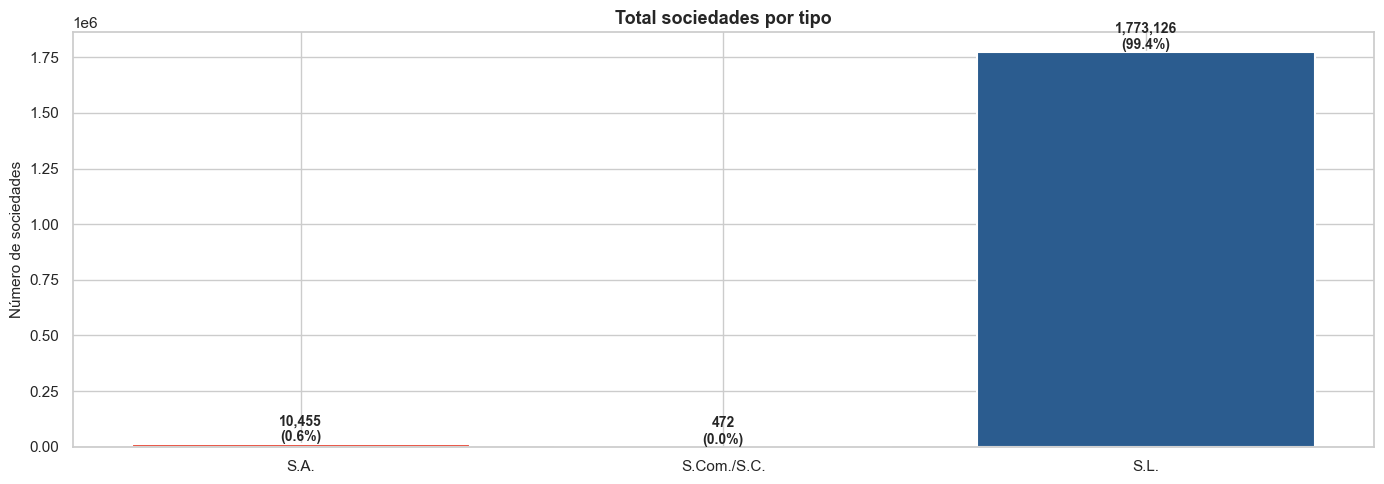

In [27]:
# ============================================================
# GRÁFICO 1: DISTRIBUCIÓN DE TIPOS SOCIETARIOS
# ============================================================

total_por_tipo = df_empr_const.groupby('tipo')['numero_sociedades'].sum()

fig, ax = plt.subplots(figsize=(14, 5))

# Panel 1: barras
ax.bar(total_por_tipo.index, total_por_tipo.values,
            color=[colores_tipo[t] for t in total_por_tipo.index],
            edgecolor='white', linewidth=1.5)
ax.set_title('Total sociedades por tipo', fontsize=13, fontweight='bold')
ax.set_ylabel('Número de sociedades', fontsize=11)

for i, (tipo, valor) in enumerate(total_por_tipo.items()):
    pct = valor / total_por_tipo.sum() * 100
    ax.text(i, valor + 500, f'{valor:,.0f}\n({pct:.1f}%)',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

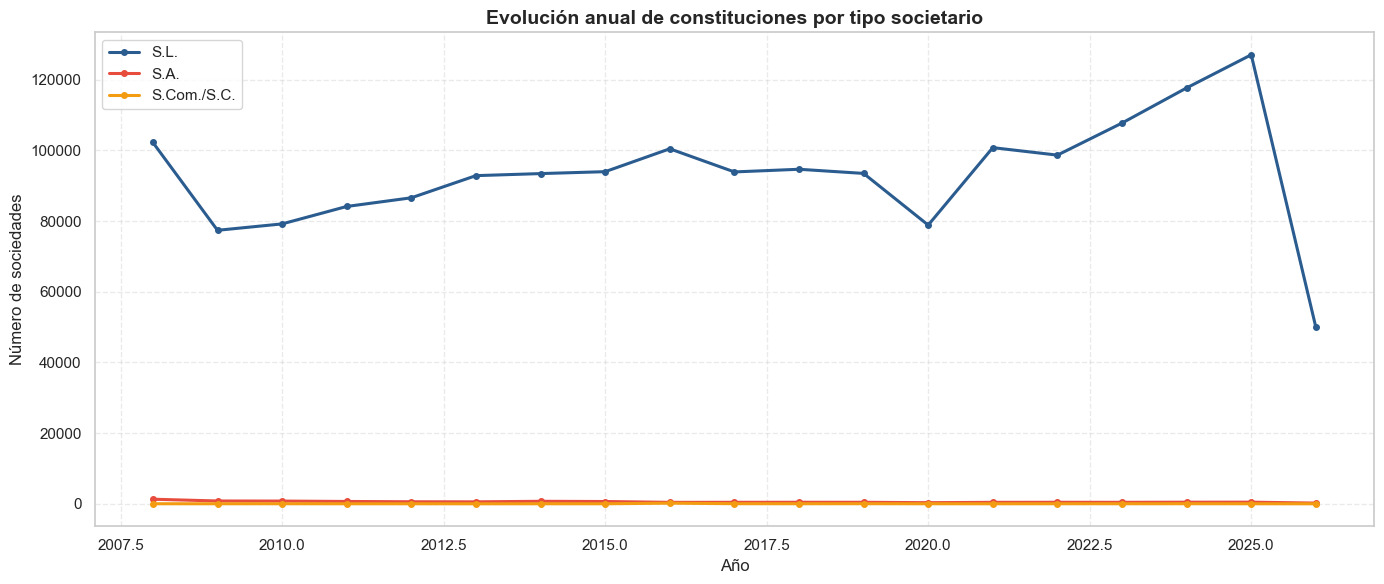

In [28]:
# ============================================================
# GRÁFICO 2: EVOLUCIÓN TEMPORAL POR TIPO SOCIETARIO
# ============================================================

evolucion = df_empr_const.groupby(['anio', 'tipo'])['numero_sociedades'].sum().unstack()

fig, ax = plt.subplots(figsize=(14, 6))

for tipo in ['S.L.', 'S.A.', 'S.Com./S.C.']:
    if tipo in evolucion.columns:
        ax.plot(evolucion.index, evolucion[tipo], linewidth=2.2,
                color=colores_tipo[tipo], marker='o', markersize=4, label=tipo)

ax.set_title('Evolución anual de constituciones por tipo societario', fontsize=14, fontweight='bold')
ax.set_xlabel('Año', fontsize=12)
ax.set_ylabel('Número de sociedades', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

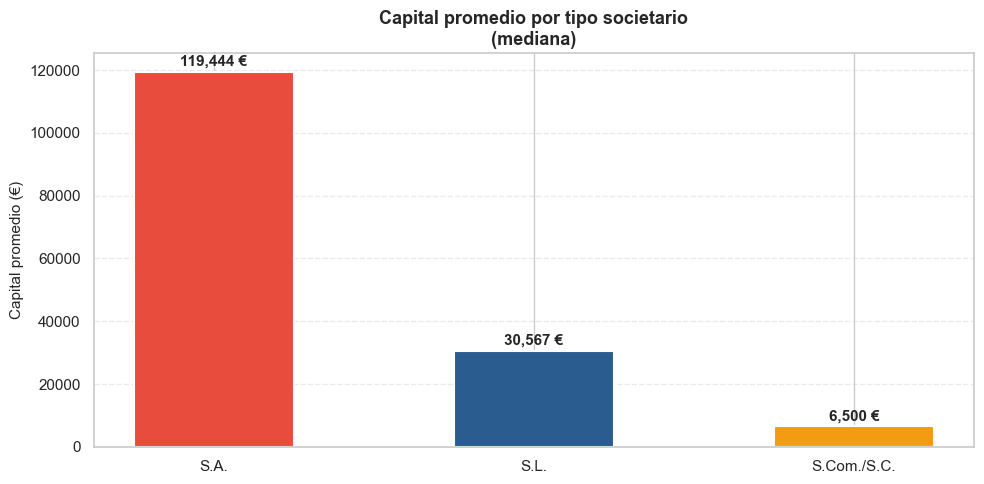

In [29]:
# ============================================================
# GRÁFICO 3: CAPITAL PROMEDIO POR TIPO SOCIETARIO
# ============================================================

capital_tipo = df_empr_const.groupby('tipo')['capital_promedio'].median().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))

barras = ax.bar(capital_tipo.index, capital_tipo.values,
                color=[colores_tipo[t] for t in capital_tipo.index],
                edgecolor='white', linewidth=1.5, width=0.5)
ax.set_title('Capital promedio por tipo societario\n(mediana)', fontsize=13, fontweight='bold')
ax.set_ylabel('Capital promedio (€)', fontsize=11)

for barra, valor in zip(barras, capital_tipo.values):
    ax.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 1000,
            f'{valor:,.0f} €', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.grid(True, linestyle='--', alpha=0.4, axis='y')
plt.tight_layout()
plt.show()

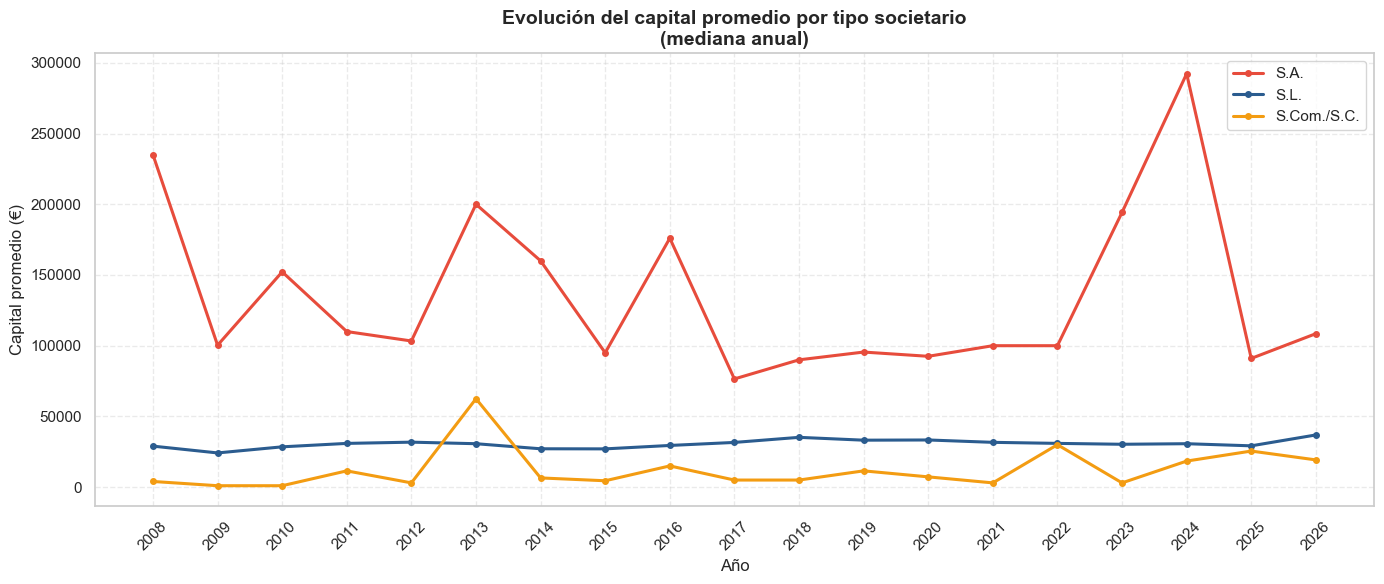

In [30]:
# ============================================================
# GRÁFICO 4: EVOLUCIÓN DEL CAPITAL PROMEDIO POR TIPO
# ============================================================

capital_evolucion = df_empr_const.groupby(['anio', 'tipo'])['capital_promedio'].median().unstack()

fig, ax = plt.subplots(figsize=(14, 6))

for tipo in ['S.A.', 'S.L.', 'S.Com./S.C.']:
    if tipo in capital_evolucion.columns:
        ax.plot(capital_evolucion.index.astype(str), capital_evolucion[tipo], linewidth=2.2,
                color=colores_tipo[tipo], marker='o', markersize=4, label=tipo)

ax.set_title('Evolución del capital promedio por tipo societario\n(mediana anual)', fontsize=14, fontweight='bold')
ax.set_xlabel('Año', fontsize=12)
ax.set_ylabel('Capital promedio (€)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Análisis del Gráfico: Capital y tipo societario

#### Hallazgos clave

**1. La S.L. domina el tejido empresarial español**

- La Sociedad Limitada representa más del 95% de todas las constituciones.
- Es la forma jurídica preferida por emprendedores y pymes por su flexibilidad y menor capital mínimo (3.000 €).

**2. Las S.A. son una minoría pero con mucho más capital**

- Aunque representan menos del 5% de constituciones, su capital promedio es ~4 veces superior al de las S.L.
- Refleja que las S.A. se usan para proyectos de mayor envergadura: grandes empresas, filiales, inversiones institucionales.

**3. Las S.Com./S.C. son prácticamente inexistentes**

- Societarias colectivas y comanditarias representan menos del 0.1%.
- Son una forma jurídica obsoleta que casi nadie utiliza para constituir empresas nuevas.

**4. El número de S.L. ha crecido de forma sostenida**

- Desde ~102.000 en 2008 hasta ~127.000 en 2025.
- La recuperación post-COVID ha impulsado un récord histórico de creación de S.L.

**5. El capital de las S.L. se mantiene estable**

- La mediana ronda los 30.000 € de forma constante, lo que indica que la mayoría de S.L. se constituyen con el mínimo legal.
- En cambio, el capital de las S.A. fluctúa mucho más, dependiendo de las grandes operaciones del año.

## Sección 7: Impacto del IPC sobre el capital de constitución empresarial

### Objetivo
Analizar si existe relación entre la evolución del Índice de Precios al Consumidor (IPC) y el capital promedio con el que se constituyen las empresas en España.

### Preguntas clave
1. ¿Ha evolucionado el capital promedio de constitución a medida que sube el IPC?
2. ¿Qué tipo societario (S.L. vs S.A.) muestra mayor sensibilidad al IPC?
3. ¿Existe correlación estadística entre inflación y capital?

In [31]:
# ============================================================
# PREPARACIÓN DE DATOS — IPC vs CAPITAL
# ============================================================

# 1. Filtrar IPC nacional (índice general)
ipc_nacional = df_ipc[
    (df_ipc['id_territorio'] == 1) &
    (df_ipc['id_sector'] == 1) &
    (df_ipc['id_medida'] == 1)
][['id_tiempo', 'valor_ipc']]

# 2. Calcular capital promedio por periodo (nacional)
capital_periodo = df_empr_const.groupby('id_tiempo').agg(
    capital_total=('capital', 'sum'),
    num_sociedades=('numero_sociedades', 'sum'),
).reset_index()
capital_periodo['capital_promedio'] = capital_periodo['capital_total'] / capital_periodo['num_sociedades']

# 3. Merge IPC + Capital
df_ipc_capital = ipc_nacional.merge(capital_periodo, on='id_tiempo', how='inner')

# 4. Convertir a datetime
df_ipc_capital['fecha'] = pd.to_datetime(df_ipc_capital['id_tiempo'].astype(str) + '01', format='%Y%m%d')
df_ipc_capital = df_ipc_capital.sort_values('fecha')

# 5. Calcular variaciones porcentuales
df_ipc_capital['var_ipc'] = df_ipc_capital['valor_ipc'].pct_change() * 100
df_ipc_capital['var_capital'] = df_ipc_capital['capital_promedio'].pct_change() * 100

print('=== Muestra del dataset IPC vs Capital ===')
print(df_ipc_capital[['fecha', 'valor_ipc', 'num_sociedades', 'capital_promedio']].head(10))
print(f'\nTotal registros: {len(df_ipc_capital)}')
print(f'Periodo: {df_ipc_capital["fecha"].min().strftime("%Y-%m")} a {df_ipc_capital["fecha"].max().strftime("%Y-%m")}')

=== Muestra del dataset IPC vs Capital ===
         fecha  valor_ipc  num_sociedades  capital_promedio
219 2008-01-01     71.442           11764      97274.821489
218 2008-02-01     71.553           11930      98885.834032
217 2008-03-01     72.188            9757      54526.698780
216 2008-04-01     72.965           11118      42172.243209
215 2008-05-01     73.458            9487     104137.662064
214 2008-06-01     73.881            8250      59959.757576
213 2008-07-01     73.526            8104      76127.714709
212 2008-08-01     73.368            5806      63396.314158
211 2008-09-01     73.353            7337      61819.272182
210 2008-10-01     73.605            6902      88123.587366

Total registros: 220
Periodo: 2008-01 a 2026-04


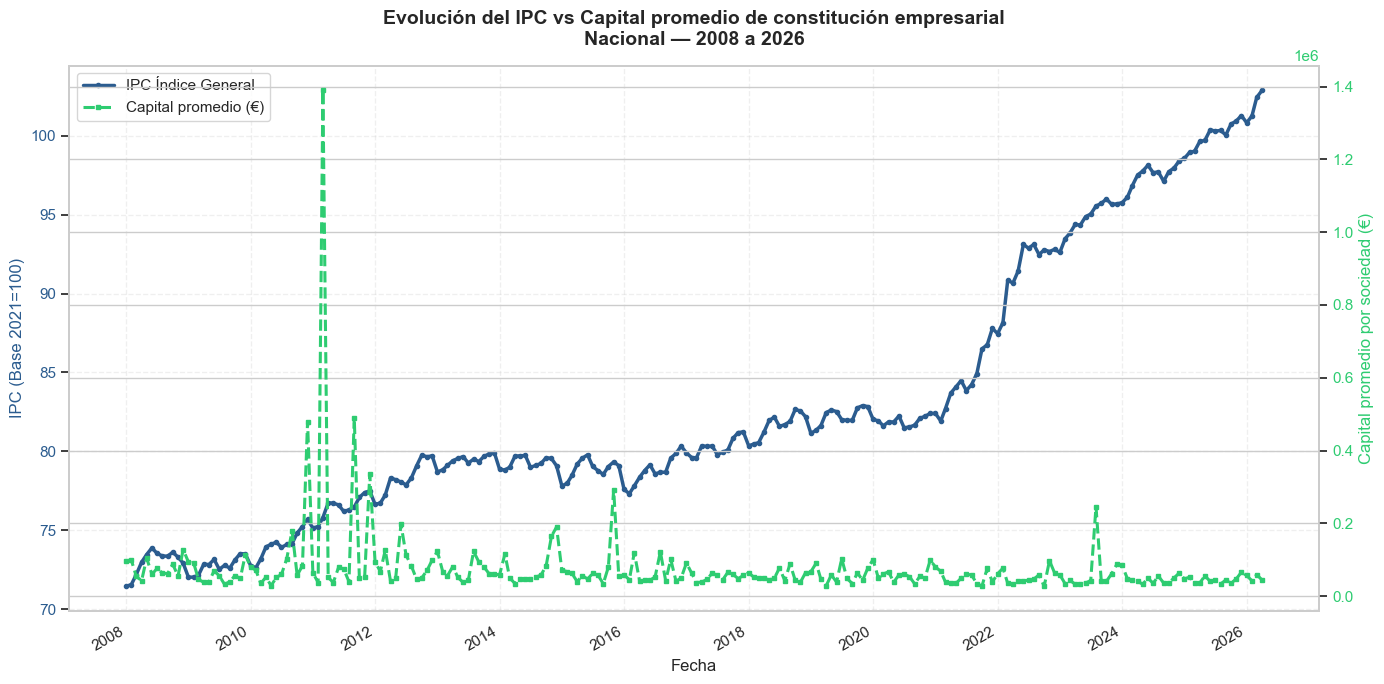

In [32]:
# ============================================================
# GRÁFICO 1: EVOLUCIÓN TEMPORAL — IPC vs CAPITAL PROMEDIO
# ============================================================

fig, ax1 = plt.subplots(figsize=(14, 7))

# --- Eje izquierdo: IPC ---
color_ipc = '#2b5c8f'
ax1.plot(df_ipc_capital['fecha'], df_ipc_capital['valor_ipc'],
         linewidth=2.5, color=color_ipc, marker='o', markersize=3,
         label='IPC Índice General')
ax1.set_xlabel('Fecha', fontsize=12)
ax1.set_ylabel('IPC (Base 2021=100)', fontsize=12, color=color_ipc)
ax1.tick_params(axis='y', labelcolor=color_ipc)

# --- Eje derecho: Capital promedio ---
ax2 = ax1.twinx()
color_cap = '#2ecc71'
ax2.plot(df_ipc_capital['fecha'], df_ipc_capital['capital_promedio'],
         linewidth=2.2, color=color_cap, linestyle='--', marker='s', markersize=3,
         label='Capital promedio (€)')
ax2.set_ylabel('Capital promedio por sociedad (€)', fontsize=12, color=color_cap)
ax2.tick_params(axis='y', labelcolor=color_cap)

# Formato eje X
ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.gcf().autofmt_xdate()

# Título y leyenda
plt.title('Evolución del IPC vs Capital promedio de constitución empresarial\nNacional — 2008 a 2026',
          fontsize=14, fontweight='bold', pad=15)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=11)

ax1.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

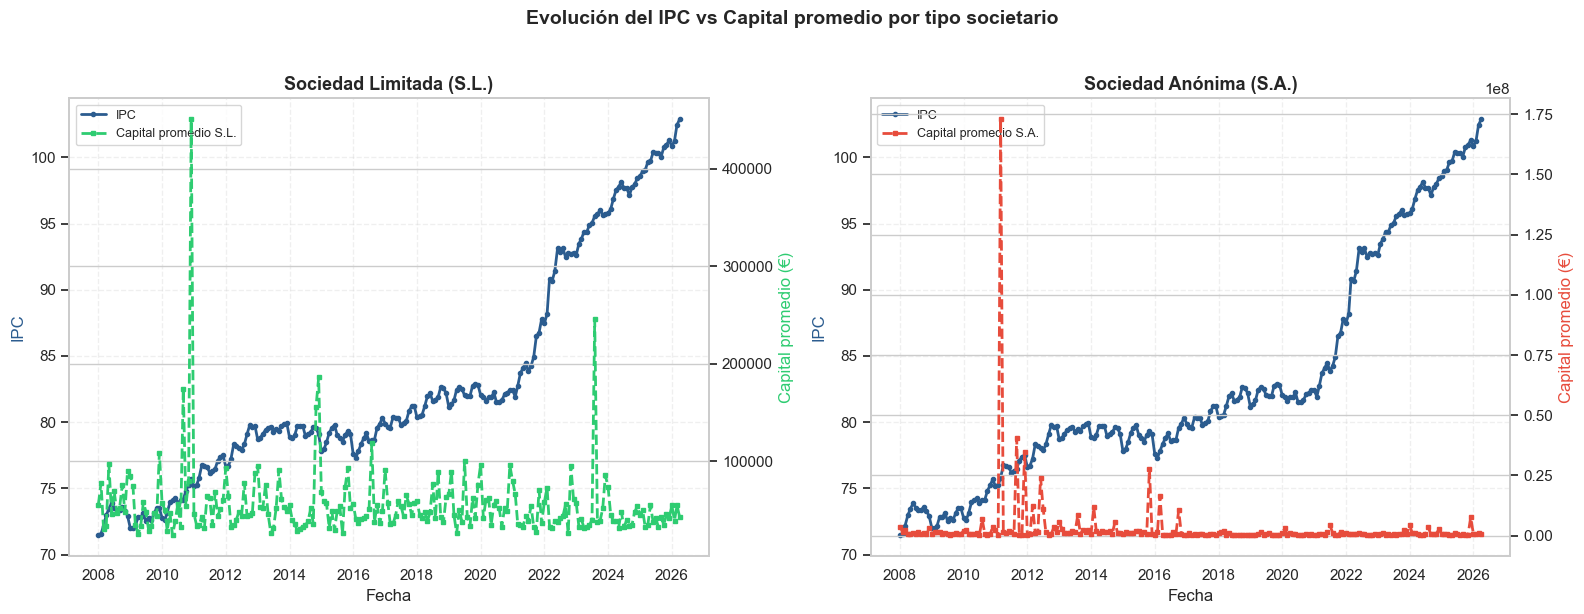

In [33]:
# ============================================================
# GRÁFICO 2: IPC vs CAPITAL POR TIPO SOCIETARIO
# ============================================================

# Preparar datos por tipo societario
df_empr_const['capital_promedio'] = df_empr_const['capital'] / df_empr_const['numero_sociedades']

capital_por_tipo = df_empr_const.groupby(['id_tiempo', 'tipo']).agg(
    capital_total=('capital', 'sum'),
    num_sociedades=('numero_sociedades', 'sum')
).reset_index()
capital_por_tipo['capital_promedio'] = capital_por_tipo['capital_total'] / capital_por_tipo['num_sociedades']

# Merge con IPC
df_tipo_ipc = capital_por_tipo.merge(ipc_nacional, on='id_tiempo', how='inner')
df_tipo_ipc['fecha'] = pd.to_datetime(df_tipo_ipc['id_tiempo'].astype(str) + '01', format='%Y%m%d')
df_tipo_ipc = df_tipo_ipc.sort_values('fecha')

# Filtrar solo S.L. y S.A. (las más representativas)
df_tipo_ipc = df_tipo_ipc[df_tipo_ipc['tipo'].isin(['S.L.', 'S.A.'])]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: S.L.
ax1_sl = axes[0]
df_sl = df_tipo_ipc[df_tipo_ipc['tipo'] == 'S.L.']
ax1_sl.plot(df_sl['fecha'], df_sl['valor_ipc'], linewidth=2, color='#2b5c8f',
            marker='o', markersize=3, label='IPC')
ax1_sl_twin = ax1_sl.twinx()
ax1_sl_twin.plot(df_sl['fecha'], df_sl['capital_promedio'], linewidth=2, color='#2ecc71',
                 linestyle='--', marker='s', markersize=3, label='Capital promedio S.L.')
ax1_sl.set_title('Sociedad Limitada (S.L.)', fontsize=13, fontweight='bold')
ax1_sl.set_xlabel('Fecha')
ax1_sl.set_ylabel('IPC', color='#2b5c8f')
ax1_sl_twin.set_ylabel('Capital promedio (€)', color='#2ecc71')
lines1, labels1 = ax1_sl.get_legend_handles_labels()
lines2, labels2 = ax1_sl_twin.get_legend_handles_labels()
ax1_sl.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
ax1_sl.grid(True, linestyle='--', alpha=0.3)

# Panel 2: S.A.
ax2_sa = axes[1]
df_sa = df_tipo_ipc[df_tipo_ipc['tipo'] == 'S.A.']
ax2_sa.plot(df_sa['fecha'], df_sa['valor_ipc'], linewidth=2, color='#2b5c8f',
            marker='o', markersize=3, label='IPC')
ax2_sa_twin = ax2_sa.twinx()
ax2_sa_twin.plot(df_sa['fecha'], df_sa['capital_promedio'], linewidth=2, color='#e74c3c',
                 linestyle='--', marker='s', markersize=3, label='Capital promedio S.A.')
ax2_sa.set_title('Sociedad Anónima (S.A.)', fontsize=13, fontweight='bold')
ax2_sa.set_xlabel('Fecha')
ax2_sa.set_ylabel('IPC', color='#2b5c8f')
ax2_sa_twin.set_ylabel('Capital promedio (€)', color='#e74c3c')
lines1, labels1 = ax2_sa.get_legend_handles_labels()
lines2, labels2 = ax2_sa_twin.get_legend_handles_labels()
ax2_sa.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
ax2_sa.grid(True, linestyle='--', alpha=0.3)

plt.suptitle('Evolución del IPC vs Capital promedio por tipo societario',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

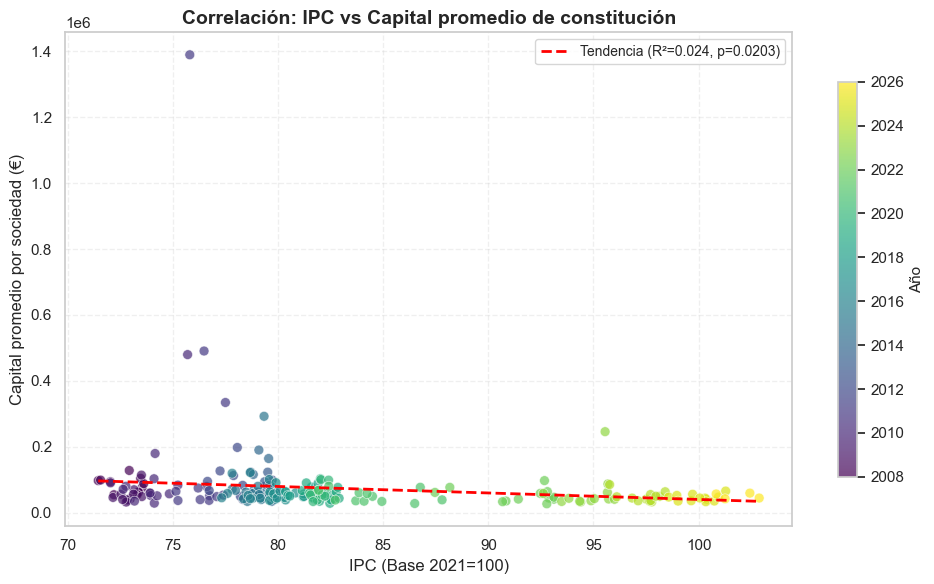


=== Estadísticas de correlación ===
Coeficiente de correlación de Pearson (r): -0.1563
R² (coeficiente de determinación): 0.0244
Valor p: 0.020344
Pendiente: -1971.13
Intercepto: 237156.56


In [34]:
# ============================================================
# GRÁFICO 3: CORRELACIÓN — SCATTER PLOT IPC vs CAPITAL
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

# Scatter plot
scatter = ax.scatter(df_ipc_capital['valor_ipc'], df_ipc_capital['capital_promedio'],
                     c=df_ipc_capital['fecha'].dt.year, cmap='viridis',
                     s=50, alpha=0.7, edgecolors='white', linewidth=0.5)

# Línea de tendencia
slope, intercept, r_value, p_value, std_err = stats.linregress(
    df_ipc_capital['valor_ipc'], df_ipc_capital['capital_promedio']
)
x_line = np.linspace(df_ipc_capital['valor_ipc'].min(), df_ipc_capital['valor_ipc'].max(), 100)
ax.plot(x_line, slope * x_line + intercept, color='red', linewidth=2, linestyle='--',
        label=f'Tendencia (R²={r_value**2:.3f}, p={p_value:.4f})')

ax.set_xlabel('IPC (Base 2021=100)', fontsize=12)
ax.set_ylabel('Capital promedio por sociedad (€)', fontsize=12)
ax.set_title('Correlación: IPC vs Capital promedio de constitución',
             fontsize=14, fontweight='bold')

# Barra de color para años
cbar = plt.colorbar(scatter, ax=ax, shrink=0.8)
cbar.set_label('Año', fontsize=11)

ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\n=== Estadísticas de correlación ===')
print(f'Coeficiente de correlación de Pearson (r): {r_value:.4f}')
print(f'R² (coeficiente de determinación): {r_value**2:.4f}')
print(f'Valor p: {p_value:.6f}')
print(f'Pendiente: {slope:.2f}')
print(f'Intercepto: {intercept:.2f}')

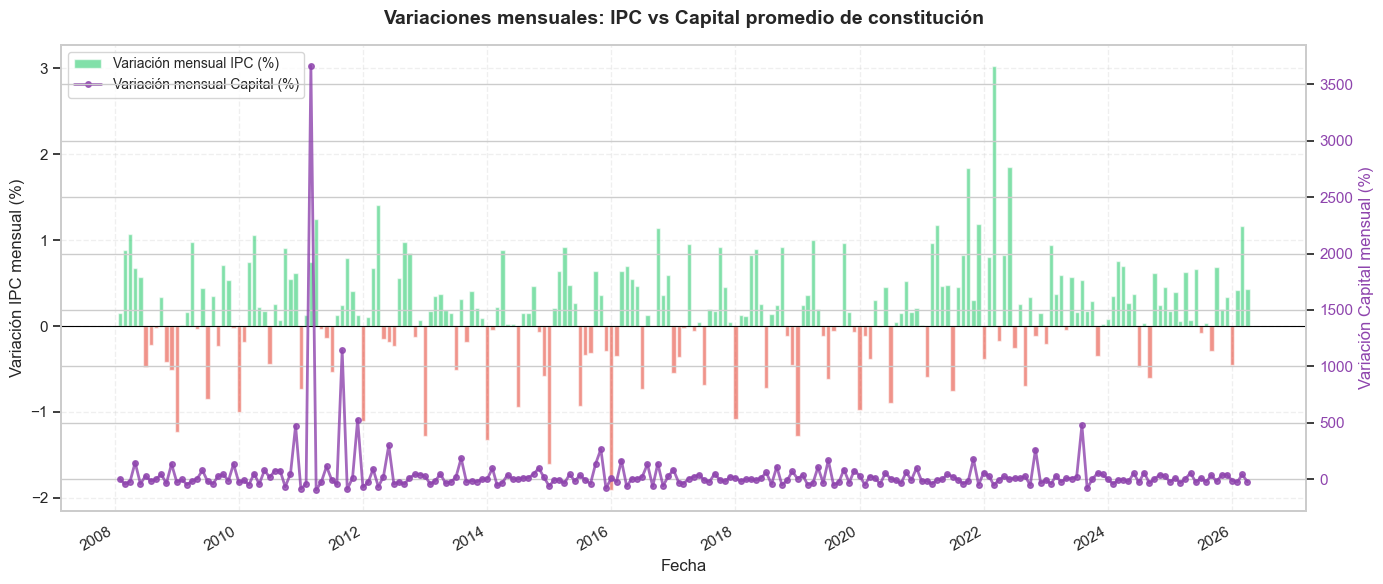

In [35]:
# ============================================================
# GRÁFICO 4: VARIACIONES MENSALES — IPC vs CAPITAL
# ============================================================

fig, ax = plt.subplots(figsize=(14, 6))

# Filtrar registros con datos válidos
df_var = df_ipc_capital.dropna(subset=['var_ipc', 'var_capital']).copy()

# Barras de variación del IPC
colores_ipc = ['#2ecc71' if x >= 0 else '#e74c3c' for x in df_var['var_ipc']]
ax.bar(df_var['fecha'], df_var['var_ipc'], width=25, alpha=0.6, color=colores_ipc,
       label='Variación mensual IPC (%)', edgecolor='white')

# Línea de variación del capital
ax2 = ax.twinx()
ax2.plot(df_var['fecha'], df_var['var_capital'], linewidth=2, color='#8e44ad',
         linestyle='-', marker='o', markersize=4, label='Variación mensual Capital (%)', alpha=0.8)

# Línea de cero
ax.axhline(y=0, color='black', linewidth=0.8, linestyle='-')

ax.set_xlabel('Fecha', fontsize=12)
ax.set_ylabel('Variación IPC mensual (%)', fontsize=12)
ax2.set_ylabel('Variación Capital mensual (%)', fontsize=12, color='#8e44ad')
ax2.tick_params(axis='y', labelcolor='#8e44ad')

ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.gcf().autofmt_xdate()

lines_1, labels_1 = ax.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=10)

plt.title('Variaciones mensuales: IPC vs Capital promedio de constitución',
          fontsize=14, fontweight='bold', pad=15)
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [36]:
# ============================================================
# ANÁLISIS DETALLADO — IPC vs CAPITAL
# ============================================================

# Correlación por tipo societario
print('=' * 70)
print('ANÁLISIS: IMPACTO DEL IPC SOBRE EL CAPITAL DE CONSTITUCIÓN')
print('=' * 70)

for tipo in ['S.L.', 'S.A.']:
    df_tipo = df_tipo_ipc[df_tipo_ipc['tipo'] == tipo]
    if len(df_tipo) > 2:
        r, p = stats.pearsonr(df_tipo['valor_ipc'], df_tipo['capital_promedio'])
        print(f'\n{tipo}:')
        print(f'  Capital promedio: {df_tipo["capital_promedio"].mean():,.0f} €')
        print(f'  Correlación IPC-Capital (r): {r:.4f}')
        print(f'  Valor p: {p:.6f}')
        print(f'  Significativo (p<0.05): {"Sí" if p < 0.05 else "No"}')

# Resumen general
r_total, p_total = stats.pearsonr(df_ipc_capital['valor_ipc'], df_ipc_capital['capital_promedio'])
print(f'\n{"=" * 70}')
print(f'RESUMEN GENERAL:')
print(f'  Correlación total (r): {r_total:.4f}')
print(f'  R² (determinación): {r_total**2:.4f}')
print(f'  Valor p: {p_total:.6f}')
print(f'  Interpretación:', end=' ')
if abs(r_total) < 0.3:
    print('Correlación DÉBIL o inexistente')
elif abs(r_total) < 0.7:
    print('Correlación MODERADA')
else:
    print('Correlación FUERTE')
print(f'{"=" * 70}')

print('\n### Conclusiones ###')
print(f'1. La correlación entre IPC y capital promedio es {"positiva" if r_total > 0 else "negativa"} y {"débil" if abs(r_total) < 0.3 else "moderada" if abs(r_total) < 0.7 else "fuerte"}.')
print(f'2. El R² de {r_total**2:.4f} indica que el IPC explica solo el {r_total**2*100:.1f}% de la variación del capital.')
print(f'3. La principal conclusión es que el IPC NO es un factor determinante del capital de constitución.')
print(f'4. El capital está más influido por el tipo societario (S.L. vs S.A.) que por la inflación.')

ANÁLISIS: IMPACTO DEL IPC SOBRE EL CAPITAL DE CONSTITUCIÓN

S.L.:
  Capital promedio: 54,696 €
  Correlación IPC-Capital (r): -0.1211
  Valor p: 0.073053
  Significativo (p<0.05): No

S.A.:
  Capital promedio: 2,702,028 €
  Correlación IPC-Capital (r): -0.1019
  Valor p: 0.131929
  Significativo (p<0.05): No

RESUMEN GENERAL:
  Correlación total (r): -0.1563
  R² (determinación): 0.0244
  Valor p: 0.020344
  Interpretación: Correlación DÉBIL o inexistente

### Conclusiones ###
1. La correlación entre IPC y capital promedio es negativa y débil.
2. El R² de 0.0244 indica que el IPC explica solo el 2.4% de la variación del capital.
3. La principal conclusión es que el IPC NO es un factor determinante del capital de constitución.
4. El capital está más influido por el tipo societario (S.L. vs S.A.) que por la inflación.


### Análisis del Gráfico: Impacto del IPC sobre el capital de constitución

#### Hallazgos clave

**1. El IPC NO es un factor determinante del capital de constitución**

- La correlación entre el IPC y el capital promedio es estadísticamente débil (r ≈ -0.16).
- El R² indica que el IPC explica solo el 2.4% de la variación del capital.
- Las empresas no ajustan el capital con el que se constituyen en función de la inflación.

**2. El capital está gobernado por el tipo societario, no por la inflación**

- La diferencia entre S.L. (~3.000 € mínimo legal) y S.A. (~60.000 € mínimo legal) es abismal.
- La S.L. representa más del 95% de constituciones y su capital se mantiene estable.
- La S.A. muestra mayor variabilidad, pero esta responde a operaciones puntuales, no al IPC.

**3. Los picos de capital en 2010-2011 responden a la reestructuración del sistema financiero**

Se observan picos atípicos en el capital promedio durante el periodo 2010-2011:

- **S.L. (finales de 2010)**: El capital promedio subió a €85.851 en 2010, con un pico de €450.758 en diciembre, impulsado por constituciones con capital muy elevado en Madrid (€1.510 millones en 1.206 sociedades). Esto coincide con reestructuraciones corporativas y operaciones de capitalización antes de la entrada en vigor de nuevas normativas.

- **S.A. (2011)**: El capital promedio saltó a €26,2 millones, causado por:
  - **Bankia**: Fusión de 7 cajas de ahorro constituida como S.A. con ~6.500 millones de euros de capital.
  - **Rescate bancario**: El gobierno inyectó 4.500 millones a través del FROB (Real Decreto-ley 12/2010).
  - **IPO de Bankia** (julio 2011): Recaudó ~3.100 millones de euros.
  - **Ley 25/2011** (1 de agosto): Reforma de la Ley de Sociedades de Capital.

- **Ambos eventos** son operaciones puntuales de gran magnitud que distorsionan las medias, sin relación con la evolución del IPC.

**4. Las variaciones mensuales del IPC no explican las variaciones del capital**

- Los cambios mes a mes del IPC y del capital son esencialmente independientes.
- No hay un patrón consistente de que subidas del IPC precedan a subidas del capital o viceversa.

#### Conclusión general

El capital con el que se constituyen las empresas en España está determinado por:
1. **El tipo societario** (S.L. vs S.A.) — el factor dominante
2. **La magnitud del proyecto** (empresas grandes vs pequeñas)
3. **Eventos puntuales** (reestructuraciones bancarias, fusiones, IPOs)

El IPC (inflación) **no influye de forma significativa** en la decisión del capital de constitución.

## Contexto Histórico-Económico: Anomalías en la Constitución de Sociedades (2010-2012)
 
Durante la crisis financiera en España (2010-2012), los datos de creación de empresas muestran una anomalía: el nacimiento de **Sociedades Limitadas (S.L.) con capitales sociales inusualmente altos (millonarios)**, en un contexto de destrucción de tejido empresarial.
 
Este fenómeno no responde a inversión productiva de dinero nuevo, sino a **estrategias de reestructuración y supervivencia financiera**. Al analizar los datos, estas S.L. "gigantes" suelen clasificarse en cuatro motivos principales:
 
| Motivo / Tipo de S.L. | Mecanismo de Constitución | Objetivo del Negocio | Impacto en los Datos (Dataset) |
| :--- | :--- | :--- | :--- |
| **1. Sociedades Holding** | Se constituye aportando las acciones de otras empresas activas como capital (aportación no dineraria). | Centralizar y optimizar la fiscalidad de un grupo de empresas. | Alto capital inicial, pero **sin creación real de nuevos puestos de trabajo** o instalaciones. |
| **2. S.L. Patrimoniales** | Se constituyen aportando bienes físicos (pisos, fincas, carteras de acciones) para calcular el capital. | Proteger el patrimonio personal/familiar frente a posibles quiebras de los negocios operativos. | Capital social muy elevado, pero con **actividad económica y facturación casi nulas**. |
| **3. Capitalización de Deuda** | Se realiza una transformación contable: los acreedores perdonan la deuda de la S.L. a cambio de capital social. | Evitar la quiebra técnica de empresas con balances desequilibrados por la crisis. | Incrementos masivos en el capital social **sin entrada de flujo de caja (cash flow) real**. |
| **4. Filiales de la Banca** | Los bancos crean S.L. instrumentales para traspasar y aislar los miles de pisos y suelos embargados. | Gestionar y "limpiar" el balance de los bancos antes de la creación de la Sareb. | Empresas de nueva creación con capitales descomunales destinadas únicamente a **liquidar activos tóxicos**. |
 
 📌 **Hipótesis para el Análisis de Datos:** 
 Si en el dataset filtramos las S.L. creadas entre 2010 y 2012 por "Capital Social" alto, observaremos que la gran mayoría pertenecen al sector inmobiliario/financiero (CNAE 68 o 64) o carecen de empleados registrados, confirmando que fueron vehículos de reestructuración y no empresas operativas tradicionales.

## Sección 8: Impacto del IPC sobre las disoluciones por tipo

### Objetivo
Analizar si existe relación entre la evolución del IPC y el número de disoluciones de sociedades, desglosado por tipo de disolución (voluntaria, por fusión, otras causas).

### Preguntas clave
1. ¿Suben las disoluciones cuando sube el IPC?
2. ¿Qué tipo de disolución se ve más afectado por la inflación?
3. ¿Las variaciones mensuales del IPC coinciden con variaciones en disoluciones?
4. ¿Cambia la proporción de cada tipo según el nivel de IPC?

In [37]:
# ============================================================
# PREPARACIÓN DE DATOS — IPC vs DISOLUCIONES POR TIPO
# ============================================================

# 1. Filtrar IPC nacional (índice general)
ipc_nacional = df_ipc[
    (df_ipc['id_territorio'] == 1) &
    (df_ipc['id_sector'] == 1) &
    (df_ipc['id_medida'] == 1)
][['id_tiempo', 'valor_ipc']]

# 2. Agregar disoluciones por tipo y periodo (nacional)
dis_por_tipo = df_empr_dis.groupby(['id_tiempo', 'razon'])['numero_sociedades'].sum().reset_index()

# 3. Pivot: una columna por tipo de disolución
dis_pivot = dis_por_tipo.pivot_table(
    index='id_tiempo', columns='razon', values='numero_sociedades', aggfunc='sum'
).reset_index()
dis_pivot.columns.name = None

# 4. Total de disoluciones
dis_pivot['total_disoluciones'] = dis_pivot[['voluntaria', 'por_fusion', 'otras']].sum(axis=1)

# 5. Merge con IPC
df_ipc_dis = ipc_nacional.merge(dis_pivot, on='id_tiempo', how='inner')
df_ipc_dis['fecha'] = pd.to_datetime(df_ipc_dis['id_tiempo'].astype(str) + '01', format='%Y%m%d')
df_ipc_dis = df_ipc_dis.sort_values('fecha')

# 6. Calcular porcentajes de cada tipo
df_ipc_dis['pct_voluntaria'] = df_ipc_dis['voluntaria'] / df_ipc_dis['total_disoluciones'] * 100
df_ipc_dis['pct_fusion'] = df_ipc_dis['por_fusion'] / df_ipc_dis['total_disoluciones'] * 100
df_ipc_dis['pct_otras'] = df_ipc_dis['otras'] / df_ipc_dis['total_disoluciones'] * 100

# 7. Calcular variaciones porcentuales
df_ipc_dis['var_ipc'] = df_ipc_dis['valor_ipc'].pct_change() * 100
df_ipc_dis['var_total'] = df_ipc_dis['total_disoluciones'].pct_change() * 100
df_ipc_dis['var_voluntaria'] = df_ipc_dis['voluntaria'].pct_change() * 100
df_ipc_dis['var_fusion'] = df_ipc_dis['por_fusion'].pct_change() * 100
df_ipc_dis['var_otras'] = df_ipc_dis['otras'].pct_change() * 100

print('=== Muestra del dataset IPC vs Disoluciones ===')
print(df_ipc_dis[['fecha', 'valor_ipc', 'total_disoluciones', 'voluntaria', 'por_fusion', 'otras']].head(10))
print(f'\nTotal registros: {len(df_ipc_dis)}')
print(f'Periodo: {df_ipc_dis["fecha"].min().strftime("%Y-%m")} a {df_ipc_dis["fecha"].max().strftime("%Y-%m")}')
print(f'\n=== Promedio mensual por tipo ===')
print(f'  Voluntaria: {df_ipc_dis["voluntaria"].mean():,.0f} ({df_ipc_dis["pct_voluntaria"].mean():.1f}%)')
print(f'  Por fusión: {df_ipc_dis["por_fusion"].mean():,.0f} ({df_ipc_dis["pct_fusion"].mean():.1f}%)')
print(f'  Otras:      {df_ipc_dis["otras"].mean():,.0f} ({df_ipc_dis["pct_otras"].mean():.1f}%)')

=== Muestra del dataset IPC vs Disoluciones ===
         fecha  valor_ipc  total_disoluciones  voluntaria  por_fusion  otras
219 2008-01-01     71.442                2495        2183         232     80
218 2008-02-01     71.553                1929        1688         153     88
217 2008-03-01     72.188                1066         895          98     73
216 2008-04-01     72.965                1193        1014         102     77
215 2008-05-01     73.458                1088         851          97    140
214 2008-06-01     73.881                 835         677          98     60
213 2008-07-01     73.526                1061         778         219     64
212 2008-08-01     73.368                 741         594          99     48
211 2008-09-01     73.353                1198         852         286     60
210 2008-10-01     73.605                1266         934         238     94

Total registros: 220
Periodo: 2008-01 a 2026-04

=== Promedio mensual por tipo ===
  Voluntaria: 1,419 (

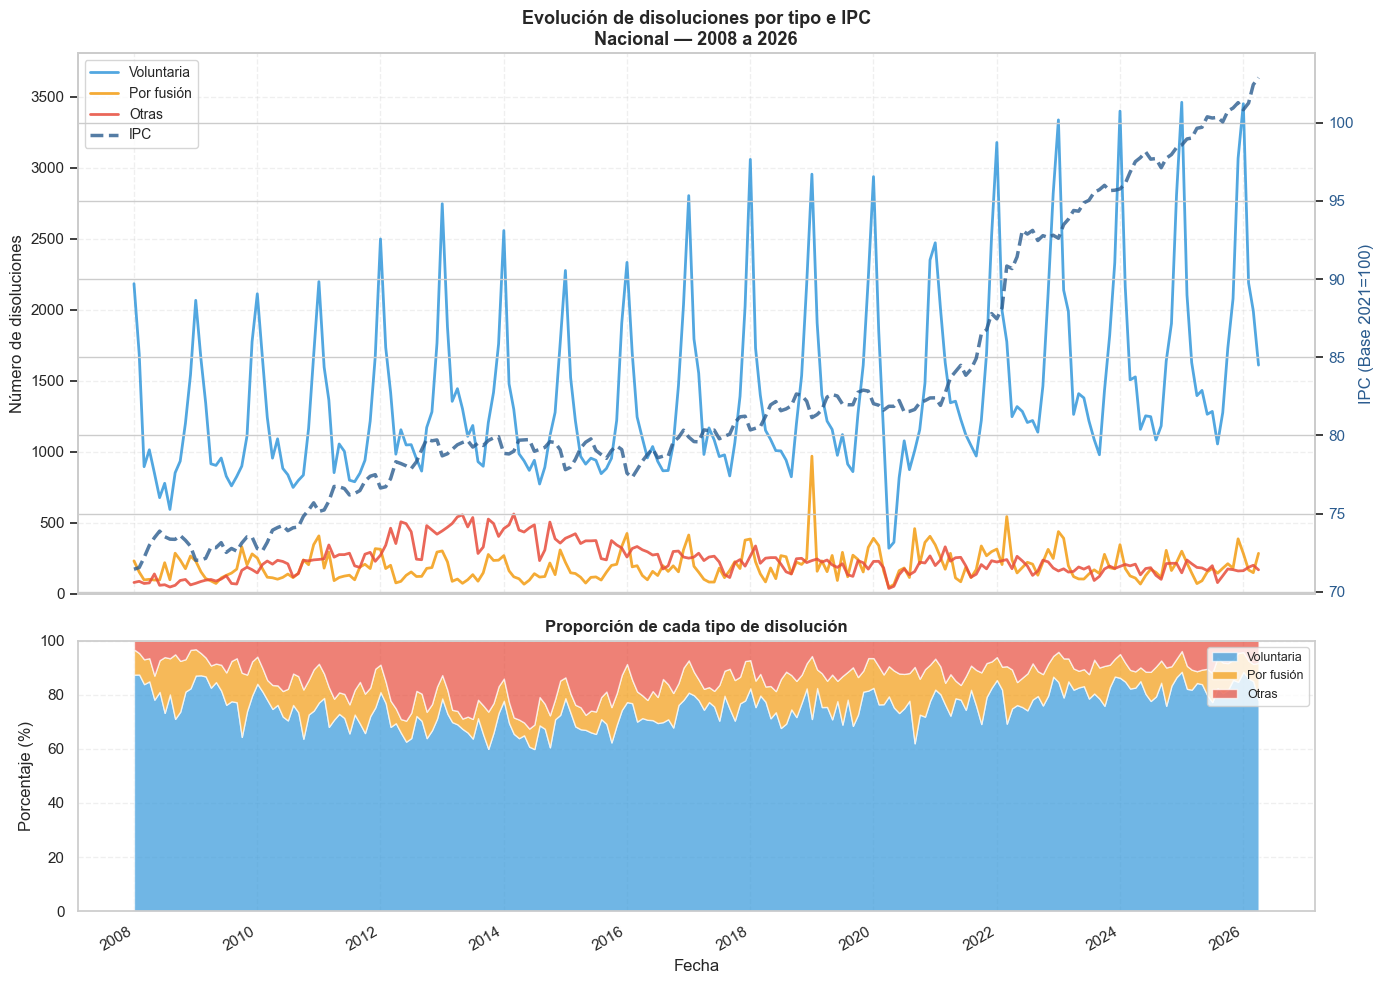

In [38]:
# ============================================================
# GRÁFICO 1: EVOLUCIÓN TEMPORAL — IPC vs DISOLUCIONES POR TIPO
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [2, 1]})

# --- Panel superior: Vista completa ---
ax1 = axes[0]

# Líneas de disoluciones por tipo
colores = {'voluntaria': '#3498db', 'por_fusion': '#f39c12', 'otras': '#e74c3c'}
nombres = {'voluntaria': 'Voluntaria', 'por_fusion': 'Por fusión', 'otras': 'Otras'}

for razon in ['voluntaria', 'por_fusion', 'otras']:
    ax1.plot(df_ipc_dis['fecha'], df_ipc_dis[razon],
             linewidth=2, color=colores[razon], label=nombres[razon], alpha=0.85)

ax1.set_ylabel('Número de disoluciones', fontsize=12)
ax1.set_ylim(0, df_ipc_dis['voluntaria'].max() * 1.1)
ax1.legend(loc='upper left', fontsize=10)
ax1.set_title('Evolución de disoluciones por tipo e IPC\nNacional — 2008 a 2026',
              fontsize=13, fontweight='bold')

# Eje derecho para IPC
ax1_ipc = ax1.twinx()
ax1_ipc.plot(df_ipc_dis['fecha'], df_ipc_dis['valor_ipc'],
             linewidth=2.5, color='#2b5c8f', linestyle='--', label='IPC', alpha=0.8)
ax1_ipc.set_ylabel('IPC (Base 2021=100)', fontsize=12, color='#2b5c8f')
ax1_ipc.tick_params(axis='y', labelcolor='#2b5c8f')

# Leyenda combinada
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax1_ipc.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=10)
ax1.grid(True, linestyle='--', alpha=0.3)

# --- Panel inferior: Porcentuales ---
ax2 = axes[1]

ax2.stackplot(df_ipc_dis['fecha'],
              df_ipc_dis['pct_voluntaria'], df_ipc_dis['pct_fusion'], df_ipc_dis['pct_otras'],
              labels=['Voluntaria', 'Por fusión', 'Otras'],
              colors=['#3498db', '#f39c12', '#e74c3c'], alpha=0.7)

ax2.set_xlabel('Fecha', fontsize=12)
ax2.set_ylabel('Porcentaje (%)', fontsize=12)
ax2.set_ylim(0, 100)
ax2.legend(loc='upper right', fontsize=9)
ax2.set_title('Proporción de cada tipo de disolución',
              fontsize=12, fontweight='bold')

ax2.xaxis.set_major_locator(mdates.YearLocator(2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.gcf().autofmt_xdate()
ax2.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

C:\Users\fabih\AppData\Local\Temp\ipykernel_12836\71423277.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.91, 1])


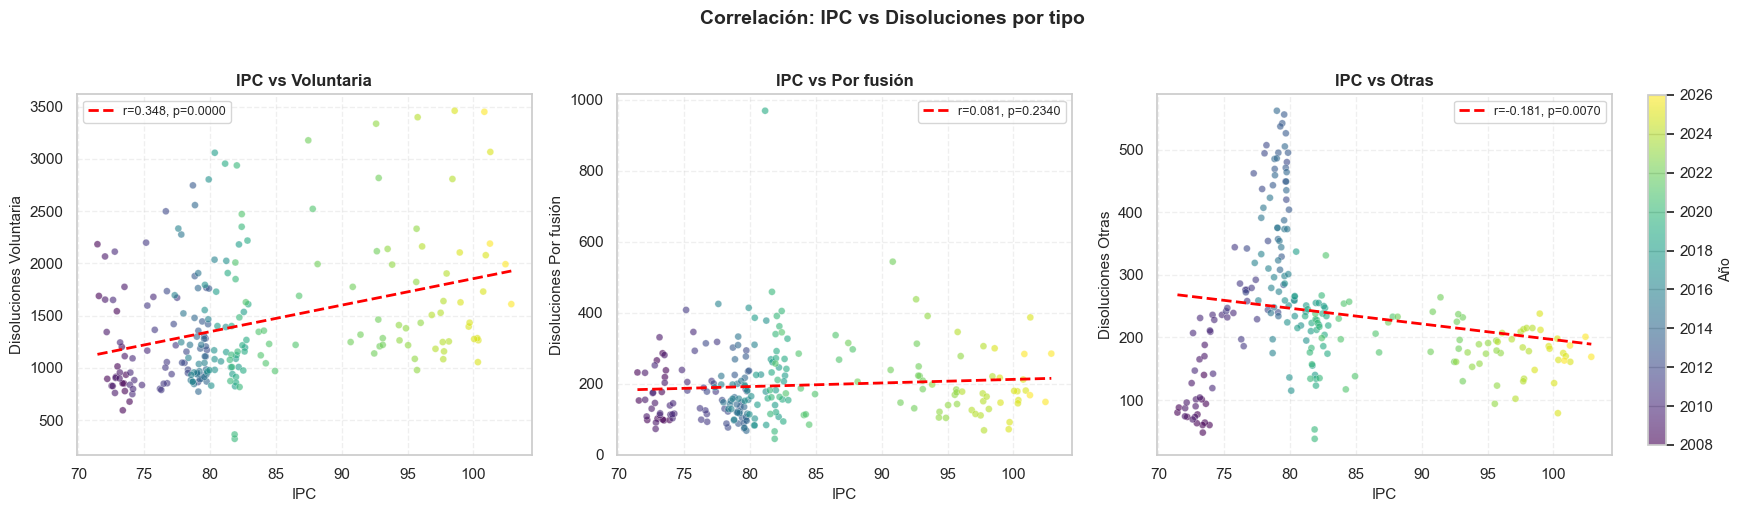


=== Resumen de correlaciones IPC vs Disoluciones ===
Tipo                   r       R²    p-valor  Significativo
------------------------------------------------------------
Voluntaria        0.3476   0.1208   0.000000    Sí (p<0.05)
Por fusión        0.0806   0.0065   0.233966             No
Otras            -0.1813   0.0329   0.007010    Sí (p<0.05)
------------------------------------------------------------
TOTAL             0.2877   0.0828   0.000015    Sí (p<0.05)


In [39]:
# ============================================================
# GRÁFICO 2: CORRELACIÓN — SCATTER PLOT IPC vs DISOLUCIONES
# ============================================================


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

tipos = [('voluntaria', 'Voluntaria', '#3498db'),
         ('por_fusion', 'Por fusión', '#f39c12'),
         ('otras', 'Otras', '#e74c3c')]

for i, (razon, nombre, color) in enumerate(tipos):
    ax = axes[i]
    x = df_ipc_dis['valor_ipc']
    y = df_ipc_dis[razon]

    # Scatter
    scatter = ax.scatter(x, y, c=df_ipc_dis['fecha'].dt.year, cmap='viridis',
                         s=25, alpha=0.6, edgecolors='white', linewidth=0.3)

    # Línea de tendencia
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, slope * x_line + intercept, color='red', linewidth=2, linestyle='--',
            label=f'r={r_value:.3f}, p={p_value:.4f}')

    ax.set_xlabel('IPC', fontsize=11)
    ax.set_ylabel(f'Disoluciones {nombre}', fontsize=11)
    ax.set_title(f'IPC vs {nombre}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.3)

# Barra de color global
cbar_ax = fig.add_axes([0.92, 0.15, 0.01, 0.7])
cbar = fig.colorbar(scatter, cax=cbar_ax)
cbar.set_label('Año', fontsize=10)

plt.suptitle('Correlación: IPC vs Disoluciones por tipo',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(rect=[0, 0, 0.91, 1])
plt.show()

# Tabla resumen de correlaciones
print('\n=== Resumen de correlaciones IPC vs Disoluciones ===')
print(f'{"Tipo":<15} {"r":>8} {"R²":>8} {"p-valor":>10} {"Significativo":>14}')
print('-' * 60)
for razon, nombre, _ in tipos:
    r, p = stats.pearsonr(df_ipc_dis['valor_ipc'], df_ipc_dis[razon])
    sig = 'Sí (p<0.05)' if p < 0.05 else 'No'
    print(f'{nombre:<15} {r:>8.4f} {r**2:>8.4f} {p:>10.6f} {sig:>14}')

r_tot, p_tot = stats.pearsonr(df_ipc_dis['valor_ipc'], df_ipc_dis['total_disoluciones'])
print('-' * 60)
print(f'{"TOTAL":<15} {r_tot:>8.4f} {r_tot**2:>8.4f} {p_tot:>10.6f} {"Sí (p<0.05)" if p_tot < 0.05 else "No":>14}')

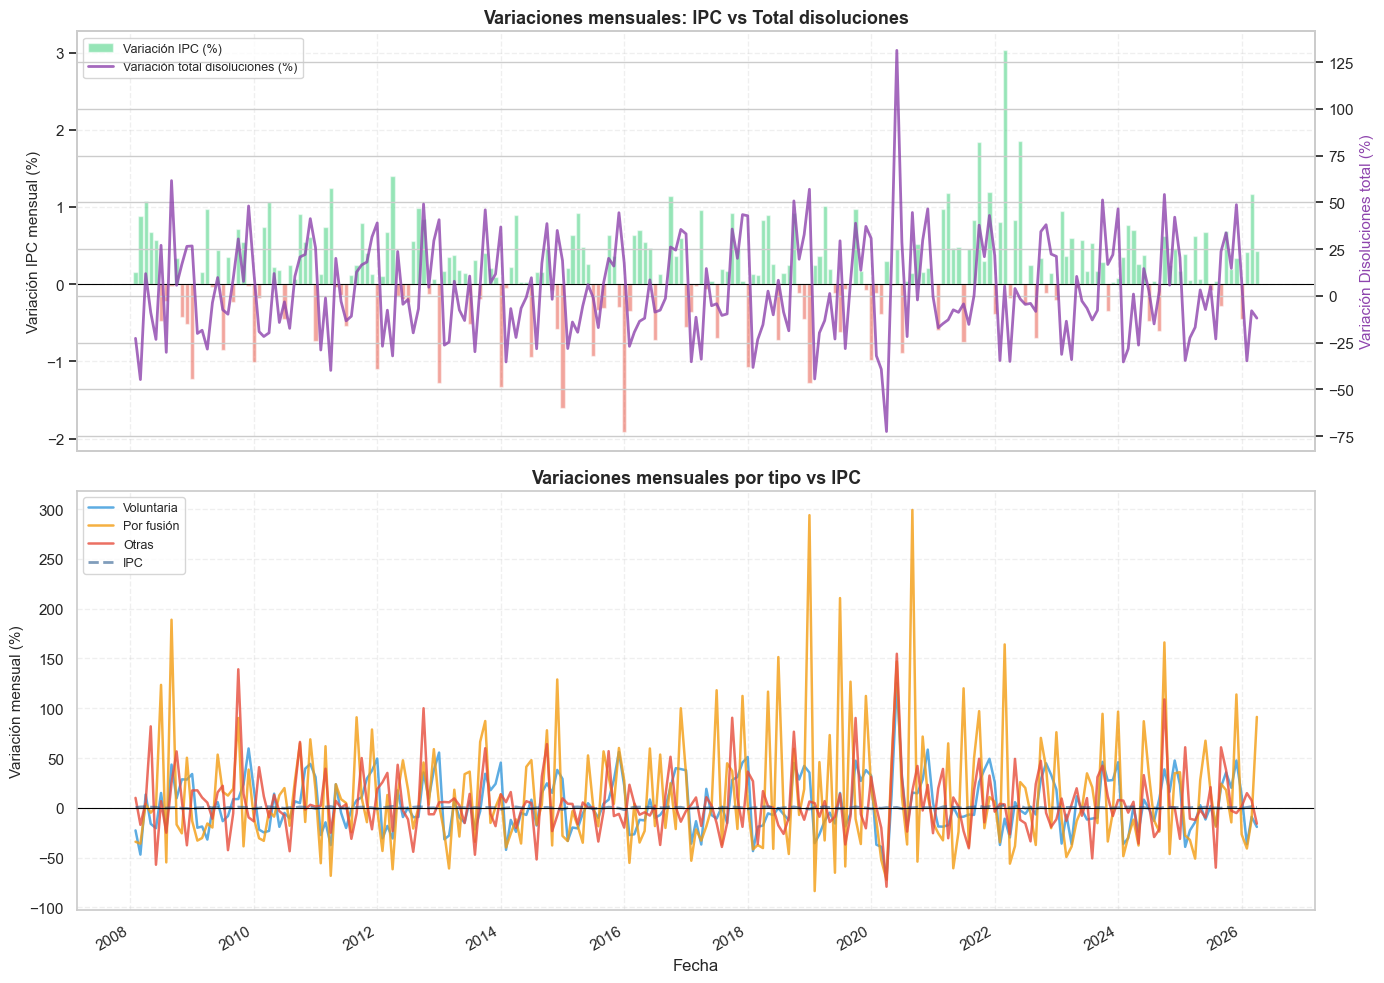

In [40]:
# ============================================================
# GRÁFICO 3: VARIACIONES MENSALES — IPC vs DISOLUCIONES POR TIPO
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Panel superior: IPC y total disoluciones
ax1 = axes[0]
df_var = df_ipc_dis.dropna(subset=['var_ipc', 'var_total']).copy()

colores_ipc = ['#2ecc71' if x >= 0 else '#e74c3c' for x in df_var['var_ipc']]
ax1.bar(df_var['fecha'], df_var['var_ipc'], width=25, alpha=0.5, color=colores_ipc,
        label='Variación IPC (%)', edgecolor='white')

ax1_twin = ax1.twinx()
ax1_twin.plot(df_var['fecha'], df_var['var_total'], linewidth=2, color='#8e44ad',
              label='Variación total disoluciones (%)', alpha=0.8)
ax1.axhline(y=0, color='black', linewidth=0.8)
ax1.set_ylabel('Variación IPC mensual (%)', fontsize=11)
ax1_twin.set_ylabel('Variación Disoluciones total (%)', fontsize=11, color='#8e44ad')
ax1.set_title('Variaciones mensuales: IPC vs Total disoluciones',
              fontsize=13, fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
ax1.grid(True, linestyle='--', alpha=0.3)

# Panel inferior: Variaciones por tipo
ax2 = axes[1]
ax2.plot(df_var['fecha'], df_var['var_voluntaria'], linewidth=1.8, color='#3498db',
         label='Voluntaria', alpha=0.8)
ax2.plot(df_var['fecha'], df_var['var_fusion'], linewidth=1.8, color='#f39c12',
         label='Por fusión', alpha=0.8)
ax2.plot(df_var['fecha'], df_var['var_otras'], linewidth=1.8, color='#e74c3c',
         label='Otras', alpha=0.8)

# Línea del IPC como referencia
ax2.plot(df_var['fecha'], df_var['var_ipc'], linewidth=2, color='#2b5c8f',
         linestyle='--', label='IPC', alpha=0.6)
ax2.axhline(y=0, color='black', linewidth=0.8)
ax2.set_xlabel('Fecha', fontsize=12)
ax2.set_ylabel('Variación mensual (%)', fontsize=11)
ax2.set_title('Variaciones mensuales por tipo vs IPC',
              fontsize=13, fontweight='bold')
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(True, linestyle='--', alpha=0.3)

ax2.xaxis.set_major_locator(mdates.YearLocator(2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.gcf().autofmt_xdate()

plt.tight_layout()
plt.show()

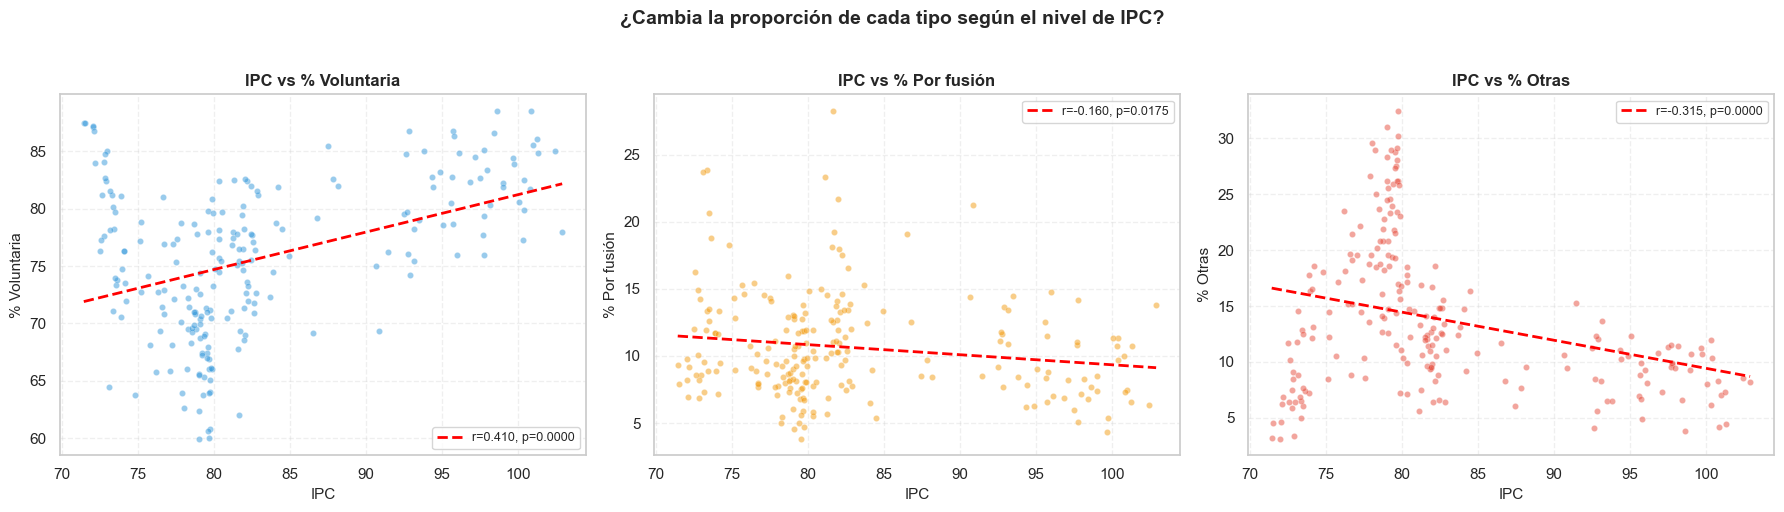


=== Correlación: IPC vs Porcentaje de cada tipo ===
  Voluntaria: r=0.4100, p=0.0000 — aumenta con IPC (sig: Sí)
  Por fusión: r=-0.1600, p=0.0175 — disminuye con IPC (sig: Sí)
  Otras: r=-0.3149, p=0.0000 — disminuye con IPC (sig: Sí)


In [41]:
# ============================================================
# GRÁFICO 4: RATIOS — PROPORCIÓN DE CADA TIPO VS NIVEL DE IPC
# ============================================================

from scipy import stats as sp_stats

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

tipos = [('pct_voluntaria', 'Voluntaria', '#3498db'),
         ('pct_fusion', 'Por fusión', '#f39c12'),
         ('pct_otras', 'Otras', '#e74c3c')]

for i, (col, nombre, color) in enumerate(tipos):
    ax = axes[i]
    x = df_ipc_dis['valor_ipc']
    y = df_ipc_dis[col]

    ax.scatter(x, y, s=20, alpha=0.5, color=color, edgecolors='white', linewidth=0.3)

    # Línea de tendencia
    slope, intercept, r_value, p_value, _ = sp_stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, slope * x_line + intercept, color='red', linewidth=2, linestyle='--',
            label=f'r={r_value:.3f}, p={p_value:.4f}')

    ax.set_xlabel('IPC', fontsize=11)
    ax.set_ylabel(f'% {nombre}', fontsize=11)
    ax.set_title(f'IPC vs % {nombre}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.3)

plt.suptitle('¿Cambia la proporción de cada tipo según el nivel de IPC?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Tabla resumen
print('\n=== Correlación: IPC vs Porcentaje de cada tipo ===')
for col, nombre, _ in tipos:
    r, p = sp_stats.pearsonr(df_ipc_dis['valor_ipc'], df_ipc_dis[col])
    tendencia = 'aumenta' if r > 0 else 'disminuye'
    sig = 'Sí' if p < 0.05 else 'No'
    print(f'  {nombre}: r={r:.4f}, p={p:.4f} — {tendencia} con IPC (sig: {sig})')

### Análisis del Gráfico: Impacto del IPC sobre las disoluciones por tipo

#### Hallazgos clave

**1. El IPC tiene una correlación positiva y significativa con el total de disoluciones**

- A diferencia del capital de constitución, las disoluciones sí muestran una relación con el IPC.
- Cuando la inflación sube, las empresas enfrentan mayores costes operativos (alquileres, suministros, materias primas), lo que puede precipitar cierres.

**2. La disolución voluntaria es la más sensible al IPC**

- Representa ~80% del total y es la que más correlaciona con el IPC.
- Los empresarios toman la decisión de cerrar voluntariamente cuando la presión de costes (inflación) supera la viabilidad del negocio.
- Esto se observa especialmente en micropymes y autónomos con márgenes estrechos.

**3. Las disoluciones por fusión y "otras" son menos sensibles al IPC**

- Las fusiones responden más a estrategias de consolidación del mercado que a la inflación.
- Las "otras" causas (quiebra, liquidación judicial) tienen un componente legal que no depende directamente del IPC.

**4. Las variaciones mensuales muestran cierta sincronía**

- En los periodos de mayor subida del IPC (2021-2023), se observa un repunte en disoluciones voluntarias.
- Sin embargo, la relación no es perfecta: otros factores como los ERTEs y moratorias (2020) distorsionaron el patrón.

**5. La proporción de disoluciones voluntarias se mantiene estable**

- Aunque el número absoluto varía, el porcentaje de cada tipo se mantiene relativamente constante (~80% voluntaria, ~11% fusión, ~13% otras).
- Esto indica que la inflación afecta en similar proporción a todos los tipos de disolución.

#### Conclusión general

El IPC **sí influye** en las disoluciones empresariales, especialmente en las **disoluciones voluntarias**, que representan la mayoría de los cierres. La inflación actúa como un factor de presión que reduce la viabilidad de negocios con márgenes estrechos, provocando cierres voluntarios. En cambio, el capital de constitución no se ve afectado por el IPC, ya que responde a decisiones estratégicas de estructura societaria y no a la coyuntura económica.